# Model 0 - One Attention Head

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

In [ ]:
dir(tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_added_tokens_decoder',
 '_added_tokens_encoder',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_merges',
 '_pad',
 '_pad_token_type_id',
 '_patch_mistral_regex',
 '_post_init',
 

## Hyperparameters

In [ ]:
seq_len    = 8
embed_dim  = 2**6
batch_size = 10
n_vocab    = tokenizer.vocab_size

## Model

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

$$
A =
\operatorname{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}} + M
\right)
$$

$$
H = AV
$$

$$
\operatorname{CausalAttention}(Q,K,V)
=
H W_O
=
\operatorname{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}} + M
\right)
V W_O
$$

$$
M_{ij}
=
\begin{cases}
0, & j \le i \\
-\infty, & j > i
\end{cases}
$$

In [ ]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    self.token_embeddings   = nn.Embedding(n_vocab, embed_dim)
    self.posit_embeddings   = nn.Embedding(seq_len, embed_dim)

    self.layer_norm_attn       = nn.LayerNorm(embed_dim)
    self.key   = nn.Linear(embed_dim, embed_dim, bias = False)
    self.query = nn.Linear(embed_dim, embed_dim, bias = False)
    self.value = nn.Linear(embed_dim, embed_dim, bias = False)
    self.W0    = nn.Linear(embed_dim, embed_dim)

    self.final_layer        = nn.Linear(embed_dim, n_vocab)
    self.final_layer.weight = nn.Parameter(self.token_embeddings.weight)

  def forward(self, tok_x):

    token_embeddings = self.token_embeddings(tok_x) # [batch_size, num_tokens, embed_dim]
    posit_embeddings = self.posit_embeddings(torch.arange(tok_x.shape[-1])) # [num_tokens, embed_dim]

    x = token_embeddings + posit_embeddings # [batch_size, num_tokens, embed_dim]

    x = self.layer_norm_attn(x) # [batch_size, num_tokens, embed_dim]

    k = self.key(x)   # [batch_size, num_tokens, embed_dim]
    q = self.query(x) # [batch_size, num_tokens, embed_dim]
    v = self.value(x) # [batch_size, num_tokens, embed_dim]

    qk = q@k.transpose(-2,-1) # [batch_size, num_tokens, num_tokens]
    qk_scaled = qk * embed_dim**(-0.5)

    T = tok_x.shape[-1]
    mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
    qk_scaled = qk_scaled.masked_fill(mask, float("-inf"))

    qk_softmax = F.softmax(qk_scaled, dim = -1)
    y = qk_softmax@v
    y = self.W0(y)

    y = self.final_layer(y) / np.sqrt(embed_dim)

    return y

  def generate(self, tok_x, temperature = 1, n_new_tokens = 20):

    for _ in range(n_new_tokens):
      x        = self(tok_x[:,-seq_len:]) # [batch_size, seq_len, embed_dim]
      logs     = x[:,-1,:] # [batch_size, embed_dim]
      probs    = F.softmax(logs/temperature, dim = -1) # [batch_size, embed_dim]
      next_tok = torch.multinomial(probs, num_samples = 1) # [batch, 1]
      tok_x    = torch.cat((tok_x, next_tok), dim = 1)

    return tok_x

## Deconstruction

### forward()

#### `tok_embed`, `pos_embed`

In [ ]:
tok_x  = torch.randint(0, n_vocab, (batch_size, seq_len))
token_embeddings = nn.Embedding(n_vocab, embed_dim)

tok_embed = token_embeddings(tok_x)
tok_embed.shape

torch.Size([10, 8, 64])

`nn.Embedding` accepts 2 values: `(num_embeddings, embedding_dim)`. In our example, `num_embeddings` is `n_vocab`, i.e. the input to `nn.Embedding` contains integer indices, and each number must be lower than `num_embeddings` (in our example, lower than `n_vocab`). `embedding_dim` is the length of the vector assigned to each index. For example, `tok_x` has shape `[batch_size, num_tokens]`, meaning each element inside `tok_x` is a token ID from `0` to `n_vocab - 1`. The outcome is that for every batch and every token, we get an embedding vector of length `embedding_dim`; therefore, `token_embeddings` has shape `[batch_size, num_tokens, embed_dim]`.


In [ ]:
position_embeddings = nn.Embedding(seq_len, embed_dim)

pos_embed = position_embeddings(torch.arange(tok_x.shape[-1]))
pos_embed.shape

torch.Size([8, 64])

It works same for position embeddings, here we pass arange of length `num_tokens` taken from `tok_x`. That causes, than each index of arange get the embedding vector.

In [ ]:
x = tok_embed + pos_embed
x.shape

torch.Size([10, 8, 64])

`pos_embed` are being added to last 2 dimensions of `tok_embed` and broadcasted through every batch. Eventually we get shape of `[batch_size, num_tokens, embed_dim]`.

#### `layer_norm_1`

In [ ]:
import copy

x_pre_norm = copy.deepcopy(x.detach())

In [ ]:
layer_norm = nn.LayerNorm(embed_dim)
x = layer_norm(x)
x.shape

torch.Size([10, 8, 64])

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11065/1343297862.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(pre_dist,  'b-o', label = f'Pre- Norm embed_dim | $\mu = {pre_mean:>10.1f}$ | $\sigma = {pre_std:.1f}$')
/tmp/ipykernel_11065/1343297862.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(pre_dist,  'b-o', label = f'Pre- Norm embed_dim | $\mu = {pre_mean:>10.1f}$ | $\sigma = {pre_std:.1f}$')
/tmp/ipykernel_11065/1343297862.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(post_dist, 'r-o', label = f'Pre- Norm embed_dim | $\mu = {post_mean:>10.1f}$ | $\sigma = {post_std:.

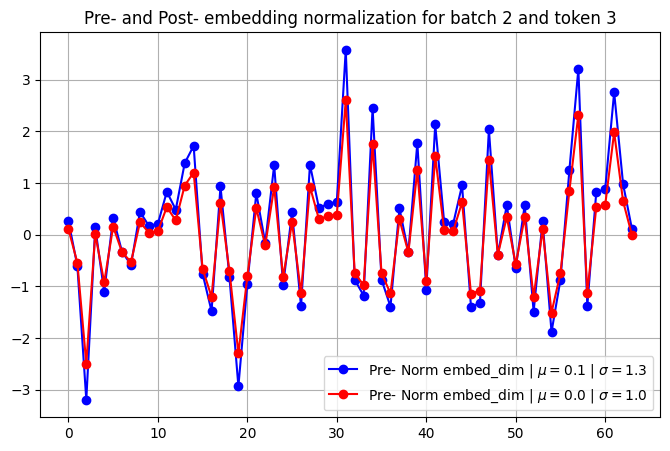

In [ ]:
rand_batch = torch.randint(0,batch_size,(1,)).item()
rand_token = torch.randint(0,x.shape[1],(1,)).item()

plt.figure(figsize = (8,5))

pre_dist  = x_pre_norm[rand_batch,rand_token,:].detach()
pre_mean = pre_dist.mean()
pre_std  = pre_dist.std()

post_dist = x[rand_batch,rand_token,:].detach()
post_mean = post_dist.mean()
post_std  = post_dist.std()

plt.plot(pre_dist,  'b-o', label = f'Pre- Norm embed_dim | $\mu = {pre_mean:>10.1f}$ | $\sigma = {pre_std:.1f}$')
plt.plot(post_dist, 'r-o', label = f'Pre- Norm embed_dim | $\mu = {post_mean:>10.1f}$ | $\sigma = {post_std:.1f}$')

plt.title(f'Pre- and Post- embedding normalization for batch {rand_batch} and token {rand_token}')
plt.legend()
plt.grid()
plt.show()

Normalization changes last dimension into $\mu = 0$ and $\sigma = 1$ what we can experience. So, last dimension which is `embed_dim` gets above parameters, in simpler words, each each token, in each batch, has vector of `embed_dim` length, this vector for each token gets normalized.

One question is why we need to pass `embed_dim` in `__init__` in `nn.LayerNorm(embed_dim)`? `nn.LayerNorm()` either way always takes last dimenion and normalizes on last dimension, then why we need to give a shape of last dimension in `__init__`? Well, that's because we want to give all parameters in `__init__`, that's how after just class instantion we can check model parameters:

In [ ]:
model = Model()

for i in model.parameters():
  print(i.shape)

torch.Size([50257, 64])
torch.Size([8, 64])
torch.Size([64])
torch.Size([64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([64])
torch.Size([50257, 64])
torch.Size([50257])


Developers theoretically could make LayerNorm infer the last dimension during the first forward pass, but then parameters like LayerNorm.weight and LayerNorm.bias would not exist immediately after __init__.

That would make model.parameters(), state_dict(), and optimizer initialization less straightforward before the first forward pass.

#### `k`,`q`,`v`

First, $W_Q$, $W_K$, $W_V$ are the raw learnable weight matrices.
Q, K, V are the projected matrices after multiplying X by those weights:

$$Q = XW_Q$$
$$K = XW_K$$
$$V = XW_V$$

in code we named $W_Q$, $W_K$, $W_V$ by `query`, `key`, `value` variables.

In [ ]:
key   = nn.Linear(embed_dim, embed_dim, bias = False)
query = nn.Linear(embed_dim, embed_dim, bias = False)
value = nn.Linear(embed_dim, embed_dim, bias = False)

K = key(x)
Q = query(x)
V = value(x)

K.shape, Q.shape, V.shape

(torch.Size([10, 8, 64]), torch.Size([10, 8, 64]), torch.Size([10, 8, 64]))

`nn.Linear(x)` is just a dot product `x@[embed_dim,embed_dim].T`

In [ ]:
embed_dim_matrix_key   = torch.randn(embed_dim, embed_dim)
embed_dim_matrix_query = torch.randn(embed_dim, embed_dim)
embed_dim_matrix_value = torch.randn(embed_dim, embed_dim)

K = x@embed_dim_matrix_key.T
Q = x@embed_dim_matrix_query.T
V = x@embed_dim_matrix_value.T

K.shape, Q.shape, V.shape

(torch.Size([10, 8, 64]), torch.Size([10, 8, 64]), torch.Size([10, 8, 64]))

We get exactly same results.

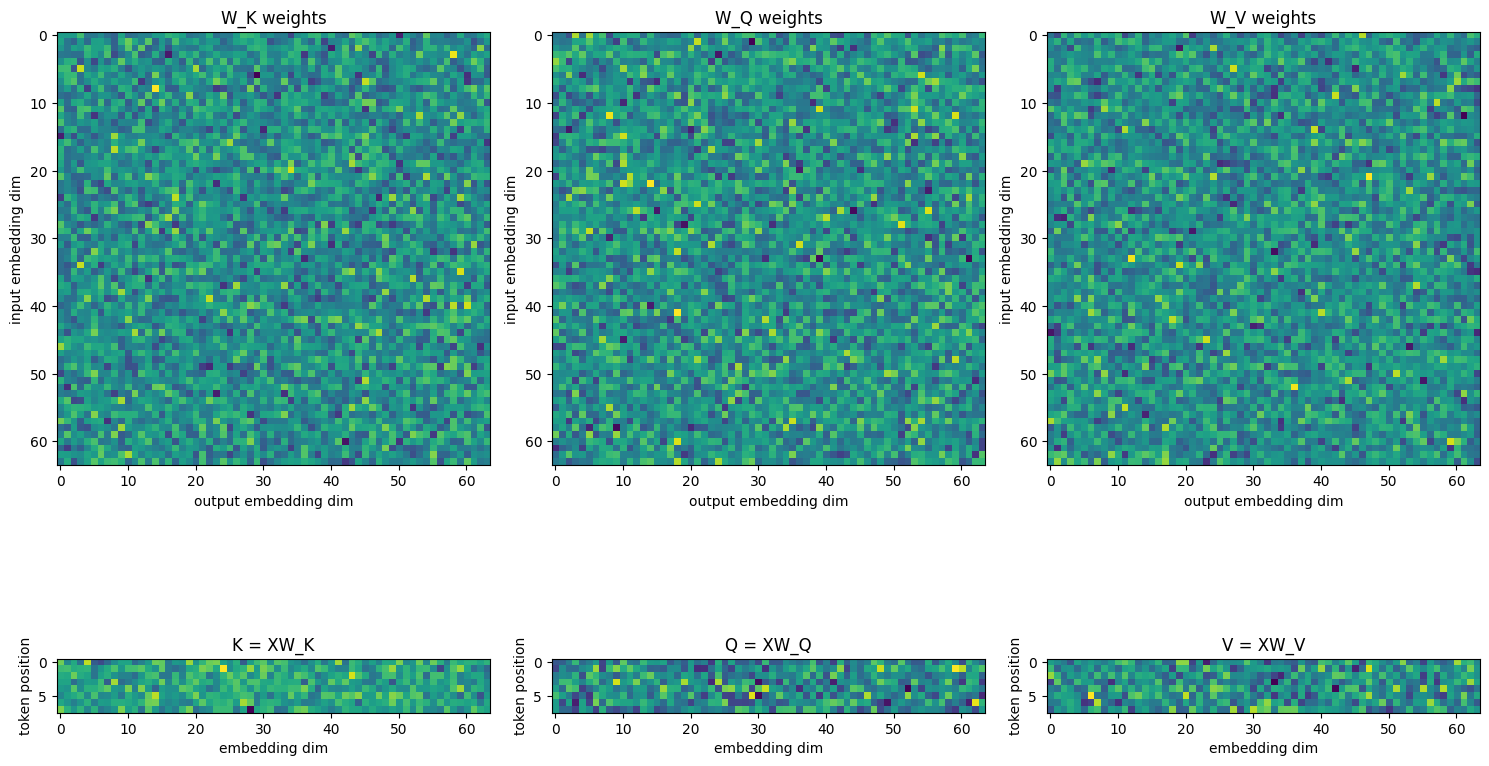

In [ ]:
weights  = [embed_dim_matrix_key, embed_dim_matrix_query, embed_dim_matrix_value]
matrices = [K, Q, V]

weight_titles = ["W_K weights", "W_Q weights", "W_V weights"]
matrix_titles = ["K = XW_K", "Q = XW_Q", "V = XW_V"]

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

# plot weight matrices
for i, w in enumerate(weights):
    axs[i].imshow(w.detach() if hasattr(w, "detach") else w)
    axs[i].set_title(weight_titles[i])
    axs[i].set_xlabel("output embedding dim")
    axs[i].set_ylabel("input embedding dim")

# plot projected K, Q, V matrices for first batch
for i, m in enumerate(matrices):
    axs[i + 3].imshow(m.detach()[0])
    axs[i + 3].set_title(matrix_titles[i])
    axs[i + 3].set_xlabel("embedding dim")
    axs[i + 3].set_ylabel("token position")

plt.tight_layout()
plt.show()

Since $W,Q,K$ are of shapes `[embed_dim,embed_dim]` and $x$ is of shape `[batch_size, num_tokens, embed_dim]` (taken from last step) we do the multiplication on last 2 dimensions matrices, so for x `[num_tokens, embed_dim]` and for $W,Q,K$ `[embed_dim, embed_dim]` after matrix multiplication we receive shape of `[num_tokens, embed_dim]` which is broadcasted through all batches, so eventually we receive `[batch_size, num_tokens, embed_dim]`.

#### `qk`

In [ ]:
K.shape, Q.shape

(torch.Size([10, 8, 64]), torch.Size([10, 8, 64]))

In [ ]:
print(K.shape)
Kt = K.transpose(-2,-1)
print(Kt.shape)

torch.Size([10, 8, 64])
torch.Size([10, 64, 8])


In [ ]:
Q.shape, Kt.shape

(torch.Size([10, 8, 64]), torch.Size([10, 64, 8]))

So we multiply $Q$ of shape `[8,64]` with $K$ of shape `[64,8]`, and this is broadcasted through all 10 batches.

The rules of multiplying more than 2 dimension matrices are:

1. We multiply actually 2 last dimensions, so when we have `[10, 8, 64]` and `[10, 64, 8]` we can multiply it because `[8, 64]` and `[64, 8]` is multipliable
2. We broadcast multiplication through all other dimensions
3. All other dimension need to either be the same, or one of them needs to be one. If are the same we broadcast same amount of times in a given dim, if only one dim is one we stretch one dim into non-one dim.
4. 3 implies that number of dimensions of 2 tensors must match

That's why we do `k.transpose(-2,-1)`, $Q$ and $K$ are both same shape tensors, we need to transpose on 2 last dimensions $k$ to make multiplication valid and broadcast it through all bathces.

That also why the output shape of $QK.T$ is in `[batch_size, num_tokens, num_toknes]`. $Q$ is given by `[batch_size, num_tokens, embed_dim]`, $K.T$ (on 2 last dimensions) is given by `[batch_size, embed_dim, num_tokens]`, then `[num_tokens, embed_dim] @ [embed_dim, num_tokens]` returns `[num_tokens, num_tokens]`, with broadcasting we get `[batch_size, num_tokens, num_tokens]`.

In [ ]:
QKt = Q@Kt
QKt.shape

torch.Size([10, 8, 8])

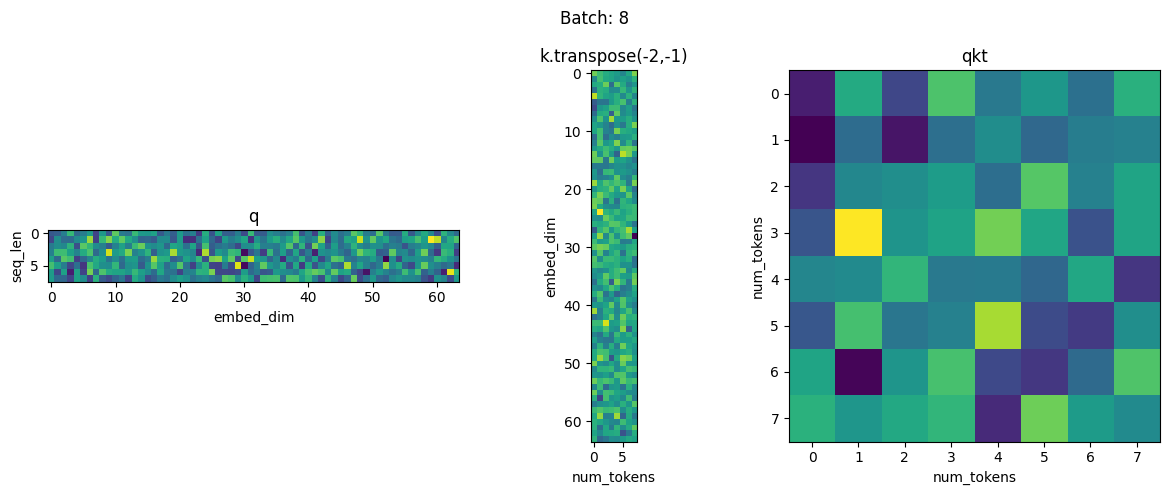

In [ ]:
fig, axs = plt.subplots(1,3,figsize = (12,5))

batch = torch.randint(0,batch_size,(1,))

axs[0].imshow(Q.detach()[0])
axs[0].set_title('q')
axs[0].set_xlabel('embed_dim')
axs[0].set_ylabel('seq_len')

axs[1].imshow(Kt.detach()[0])
axs[1].set_title('k.transpose(-2,-1)')
axs[1].set_ylabel('embed_dim')
axs[1].set_xlabel('num_tokens')

axs[2].imshow(QKt.detach()[0])
axs[2].set_title('qkt')
axs[2].set_xlabel('num_tokens')
axs[2].set_ylabel('num_tokens')

fig.suptitle(f'Batch: {batch.item()}')

plt.tight_layout()
plt.show()

#### qk_scaled

In [ ]:
qk_scaled = QKt * embed_dim**(-0.5)
qk_scaled.shape

torch.Size([10, 8, 8])

It's of course just division by square root of `embed_dim`.

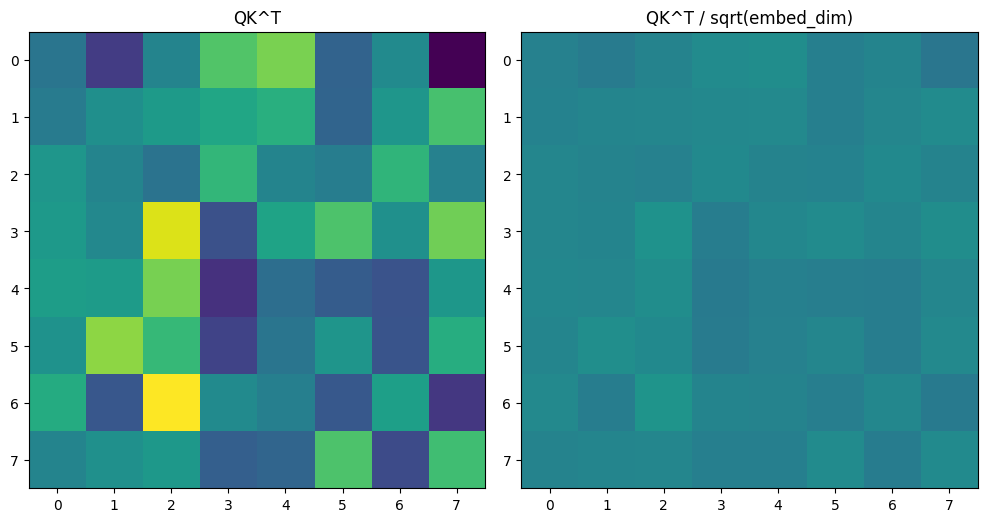

In [ ]:
vmin = QKt[rand_batch].min().item()
vmax = QKt[rand_batch].max().item()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(QKt[rand_batch].detach().squeeze(), vmin=vmin, vmax=vmax)
axs[0].set_title("QK^T")

axs[1].imshow(qk_scaled[rand_batch].detach().squeeze(), vmin=vmin, vmax=vmax)
axs[1].set_title("QK^T / sqrt(embed_dim)")

plt.tight_layout()
plt.show()

We divide by $\sqrt{\text{embed_dim}}$ because the dot product $q \cdot k$ sums over $\text{embed_dim}$ values.

As $\text{embed_dim}$ grows, the variance of $q \cdot k$ grows roughly like $\text{embed_dim}$, so its standard deviation grows like $\sqrt{\text{embed_dim}}$.

Dividing by $\sqrt{\text{embed_dim}}$ keeps attention scores in a stable range before softmax.

Without it, softmax becomes too sharp too early, almost like picking one token only.

$$
q \cdot k = \sum_{i=1}^{d_k} q_i k_i
$$

$$
\operatorname{Var}(q \cdot k) \approx d_k
$$

$$
\operatorname{Std}(q \cdot k) \approx \sqrt{d_k}
$$

$$
\frac{q \cdot k}{\sqrt{d_k}}
$$

#### `M` (mask)

In [ ]:
past_mask = torch.tril(torch.ones(batch_size, seq_len, seq_len))
qk_scaled[past_mask == 0] = -torch.inf

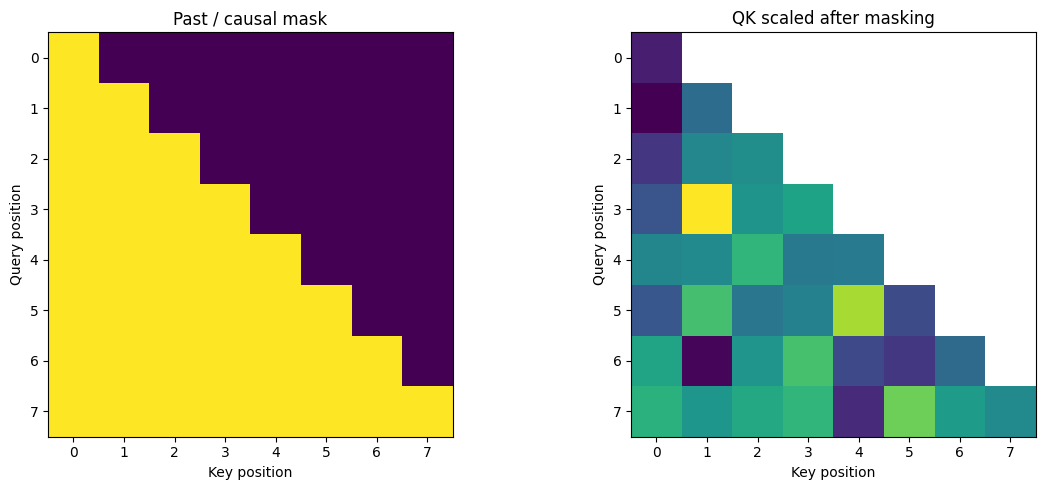

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[-114.4835,      -inf,      -inf,      -inf,      -inf,      -inf,
              -inf,      -inf],
        [-140.8005,  -32.1614,      -inf,      -inf,      -inf,      -inf,
              -inf,      -inf],
        [ -92.5305,    2.5598,   12.2005,      -inf,      -inf,      -inf,
              -inf,      -inf],
        [ -59.8641,  168.0972,   19.4802,   38.3816,      -inf,      -inf,
              -inf,      -inf],
        [   1.5021,    6.6084,   62.5078,  -16.2815,  -13.0555,      -inf,
              -inf,      -inf],
        [ -56.7761,   76.7906,  -19.5995,   -5.4900,  128.0685,  -69.7375,
              -inf,      -inf],
        [  39.0886, -

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1) causal / past mask
axs[0].imshow(past_mask[0].detach().cpu())
axs[0].set_title("Past / causal mask")
axs[0].set_xlabel("Key position")
axs[0].set_ylabel("Query position")

# 2) masked attention scores
axs[1].imshow(qk_scaled[0].detach().cpu())
axs[1].set_title("QK scaled after masking")
axs[1].set_xlabel("Key position")
axs[1].set_ylabel("Query position")

plt.tight_layout()
plt.show()

print(past_mask[0])
print(qk_scaled[0])

`past_mask` simulates time, so at top we have single word, and going forward we add more words. The thing is that the model is causal, meaning it needs to see ONLY the past. Text given for training shows also future, so we want to hide it from model, so it will be able to predict new tokens without knowing future ones.

Adding infinity instead of 0's, is just for softmax. Softmax will turn

In [ ]:
F.softmax(torch.tensor([1,2,0.]), dim = 0)

tensor([0.2447, 0.6652, 0.0900])

In [ ]:
F.softmax(torch.tensor([1, 2, -torch.inf]), dim = 0)

tensor([0.2689, 0.7311, 0.0000])

As we can see sofmtax for 0's is not 0, we want it to be just 0 that's why we get negative infinity in place of 0's.

#### `qk_softmax`

`qk_scaled` has same dimension as `qk` `[batch_size, num_tokens, num_tokens]`. We do softmax on last dimension `dim = -1`.

In [ ]:
qk_scaled.shape

torch.Size([10, 8, 8])

In [ ]:
qk_softmax = F.softmax(qk_scaled, dim = -1)
qk_softmax.shape

torch.Size([10, 8, 8])

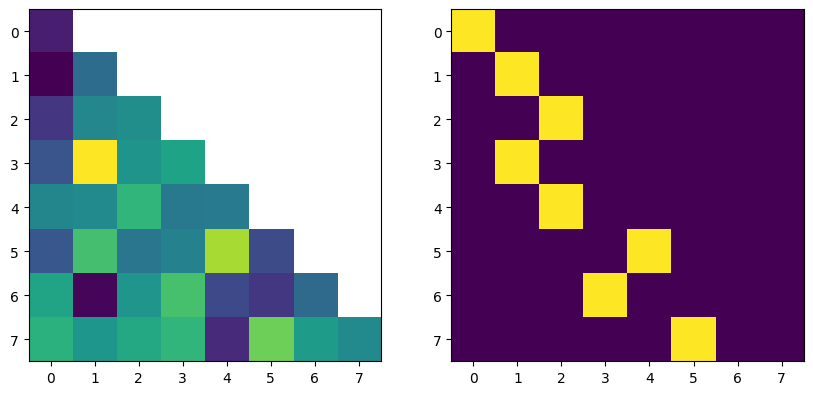

In [ ]:
fig, axs = plt.subplots(1,2, figsize = (10,5))

axs[0].imshow(qk_scaled[ 0].detach())
axs[1].imshow(qk_softmax[0].detach())

As we can see in last sequence only token of index 1 fired. 7th sequence tries to predict token 8th, i.e. for prediction of token 8th the highest importance has token 1.

The attention mechanism returns a probability distribution over the previous tokens, representing their relative importance for building the current token representation, which is then used to predict the next token in the sequence.

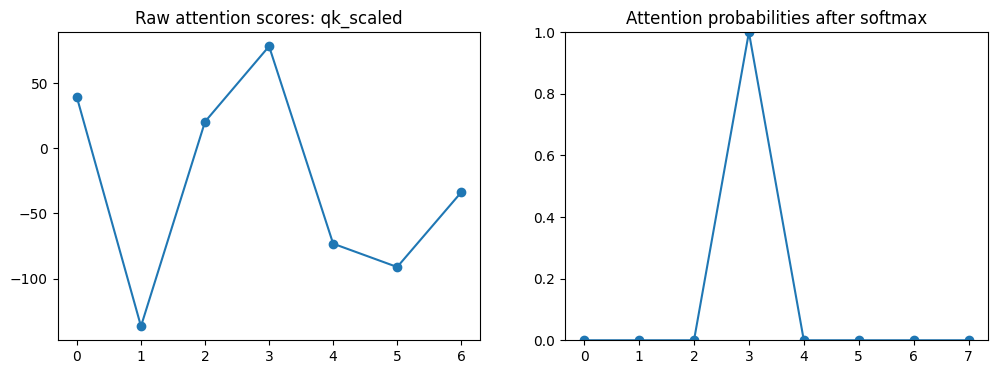

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))

axs[0].plot(qk_scaled[0,-2,:].detach(), '-o')
axs[0].set_title("Raw attention scores: qk_scaled")

axs[1].plot(qk_softmax[0,-2,:].detach(), '-o')
axs[1].set_title("Attention probabilities after softmax")
axs[1].set_ylim(0, 1)

plt.show()

Now, one very important thing: when we try to predict the token at index 7, attention looks at the previous tokens. But why do we need previous tokens?

The word “probability” can be misleading here. It is better to think of attention weights as a normalized distribution of importance, or scale factors.

This distribution tells us how much information we should take from each previous token to build the context representation for the current position. From that context representation, the model then predicts the next token.

So the previous tokens are not being predicted. They are used to represent the context for predicting the token at index 7. Attention tells us how important each previous token is for building that context.

#### `qk_sotfmax@v`

In [ ]:
qk_softmax.shape, V.shape

(torch.Size([10, 8, 8]), torch.Size([10, 8, 64]))

In [ ]:
y = qk_softmax@V
y.shape

torch.Size([10, 8, 64])

Before multiplication with $V$ we have `[batch_size, num_tokens, num_tokens]` after we receive `[batch_size, num_tokens, embed_dim]`.

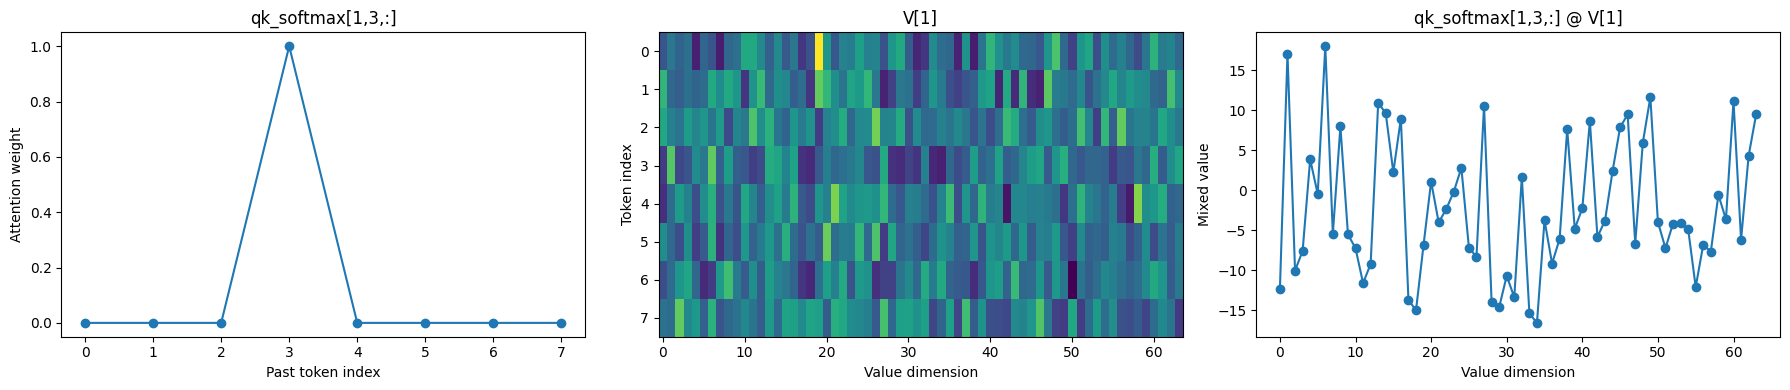

In [ ]:
b = 1
t = 3

attn = qk_softmax[b, t, :]      # [8]
v_mat = V[b]                    # [8, 64]
prod = attn @ v_mat             # [64]

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].plot(attn.detach(), "-o")
axs[0].set_title(f"qk_softmax[{b},{t},:]")
axs[0].set_xlabel("Past token index")
axs[0].set_ylabel("Attention weight")

axs[1].imshow(v_mat.detach(), aspect="auto")
axs[1].set_title(f"V[{b}]")
axs[1].set_xlabel("Value dimension")
axs[1].set_ylabel("Token index")

axs[2].plot(prod.detach(), "-o")
axs[2].set_title(f"qk_softmax[{b},{t},:] @ V[{b}]")
axs[2].set_xlabel("Value dimension")
axs[2].set_ylabel("Mixed value")

plt.tight_layout()
plt.show()

For position 3, qk_softmax gives attention weights over previous tokens.

Then we multiply these weights by V:

attention_weights @ V

This means: take a weighted mixture of value vectors from previous tokens.

So if token 1 has weight 0.9, most of the new context vector comes from V[1].
If token 2 has weight 0.1, a small part comes from V[2].
Tokens with weight near 0 contribute almost nothing.

The product is one new vector of size 64.
This vector is the context representation for position 3, and later it is used to predict the next token.

In simple words, for each token position, attention attaches back a mixed value vector of length embed_dim.

#### `y=W0(y)`

In [ ]:
import copy

y_pre = copy.copy(y)

In [ ]:
y_pre.shape

torch.Size([10, 8, 64])

In [ ]:
W0 = nn.Linear(embed_dim, embed_dim)
W0y = W0(y_pre)
W0y.shape

torch.Size([10, 8, 64])

After attention, every token gets back a mixed value vector. qk_softmax decides which previous tokens matter. V contains the information from those tokens. W0 then rewrites this mixed information back into the model space, so the next layer can use it.

Simple intuition:

* qk_softmax @ V = collect information
* W0(y) = rewrite it into useful model language

In [ ]:
y = W0y

In [ ]:
y.shape

torch.Size([10, 8, 64])

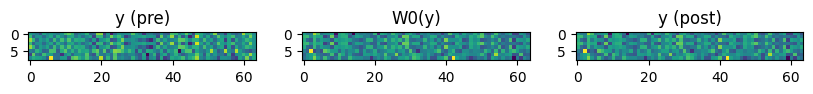

In [ ]:
_, axs = plt.subplots(1,3,figsize = (10,5))

axs[0].imshow(y_pre.detach()[0])
axs[0].set_title('y (pre)')
axs[1].imshow(W0y.detach()[0])
axs[1].set_title('W0(y)')
axs[2].imshow(y.detach()[0])
axs[2].set_title('y (post)')

plt.show()

* y = information
* W0(y) = learned gate/control signal
* y *= W0(y) = keep/use only what the model decides is useful

#### `self.final_layer(y) / np.sqrt(embed_dim)`

In [ ]:
final_layer = nn.Linear(embed_dim, n_vocab)
final_layer.weight = nn.Parameter(token_embeddings.weight)

y_pre = copy.copy(y)

y = final_layer(y_pre) / np.sqrt(embed_dim)

In [ ]:
y_pre.shape, y.shape

(torch.Size([10, 8, 64]), torch.Size([10, 8, 50257]))

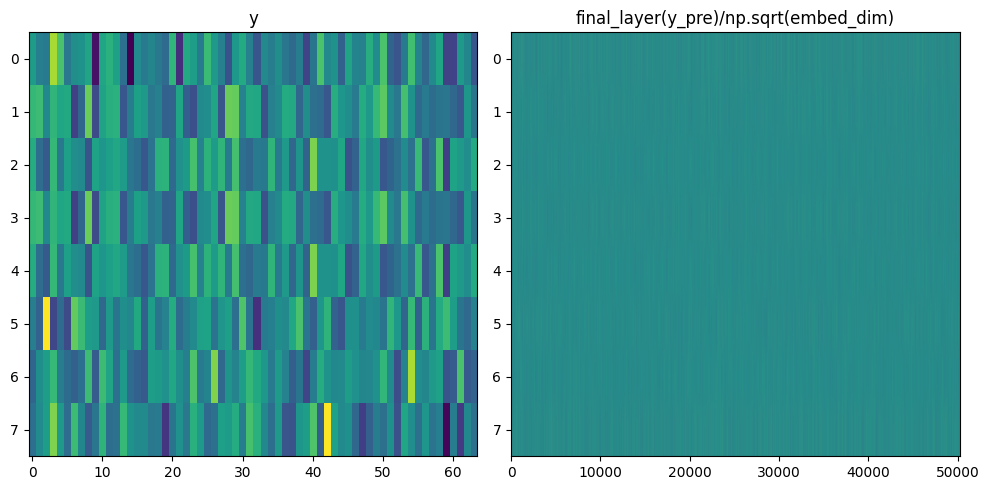

In [ ]:
_, axs = plt.subplots(1,2,figsize=(10,5))

axs[0].imshow(y_pre.detach()[0], aspect = 'auto')
axs[0].set_title('y')
axs[1].imshow(y.detach()[0],     aspect = 'auto')
axs[1].set_title('final_layer(y_pre)/np.sqrt(embed_dim)')

plt.tight_layout()
plt.show()

At this stage, we project each token vector from `embed_dim` to `n_vocab` using final_layer. So shape changes from `[batch, seq_len, embed_dim]` to `[batch, seq_len, n_vocab]`. This gives one logit score for every possible next token.

We divide by `sqrt(embed_dim)` to keep the scale of logits under control.

### generate()

generate() function design depends on what kind of behavior we want from the model.

For example, the model can:

* take text and return one next word/token

* take text with missing words and fill the blanks

* take a question and return a chat-like answer

* take a prompt and continue the text

* take instructions and return a structured output

So generate() is not one fixed thing. It is just the wrapper that controls how model outputs are turned into final text. This particular `generate()` function we build, takes some sentence, e.g. "I believe I can fly, I believe I" and model return as many new tokens we specify in `n_new_tokens`.

#### self(`tok_x[:,-seq_len:]`)


For generate() we need processed forward() function. However, we have ongoing `y` in `forward()` subsection which we can use as `self()`. `self()` is just a reference to built-in `forward()` function, i.e. `tok_x[:,-seq_len:]` goes through `forward()` function

`tok_x` represents input data, it has 10 batches with length of 8 each. Now, `seq_len` is 8. `tok_x` lenght is same as `seq_len` therefore we `tok_x[:,-seq_len:]` = `tok_x` in this particular example. In general the idea is that for each batch we take last `seq_len` tokens a sequence from which we want to make prediction of next token. That means we always feed the model with last `seq_len` tokens for prediction, no more.

In [ ]:
tok_x.shape, seq_len

(torch.Size([10, 8]), 8)

In [ ]:
y.shape

torch.Size([10, 8, 50257])

Since, `tok_x` has same width as `seq_len`, i.e. input data to forwad `tok_x` had `seq_len` width, and input to `self()` (`tok_x[:,-seq_len:]`) also has width of `seq_len` we can just do `x = y`, but it actually means `x = self(tok_x[:,-seq_len:])`

Let's apply this mental shortcut

In [ ]:
x = y # actually means x = self(tok_x[:,-seq_len:]) - shortcut to keep same flow out of instantiated Model class

In [ ]:
x.shape

torch.Size([10, 8, 50257])

Our `x` at this point has shape of `[batch_size, seq_len, n_vocab]`. Let's note one important thing, in `forward()` subsection instead of `seq_len` we used `num_tokens` as shape even though in our example `seq_len` = `num_toknes` because we generated `tok_x` with width equal to `seq_len`. However, we didn't have to do that, in forward `num_tokens` can be any positive integer, meaning we can pass to the model sentences of any length for training (later we have constraint of `context_length` which we don't use in current version of the model). BUT, in `generate()` function we take last `seq_len` tokens and we use only them to predict next token. That's why here we need to rename `num_tokens` into `seq_len`.

#### `x[:,-1,:]`

In [ ]:
x.shape

torch.Size([10, 8, 50257])

In [ ]:
logs = x[:,-1,:]
logs.shape

torch.Size([10, 50257])

In this step we simply take,

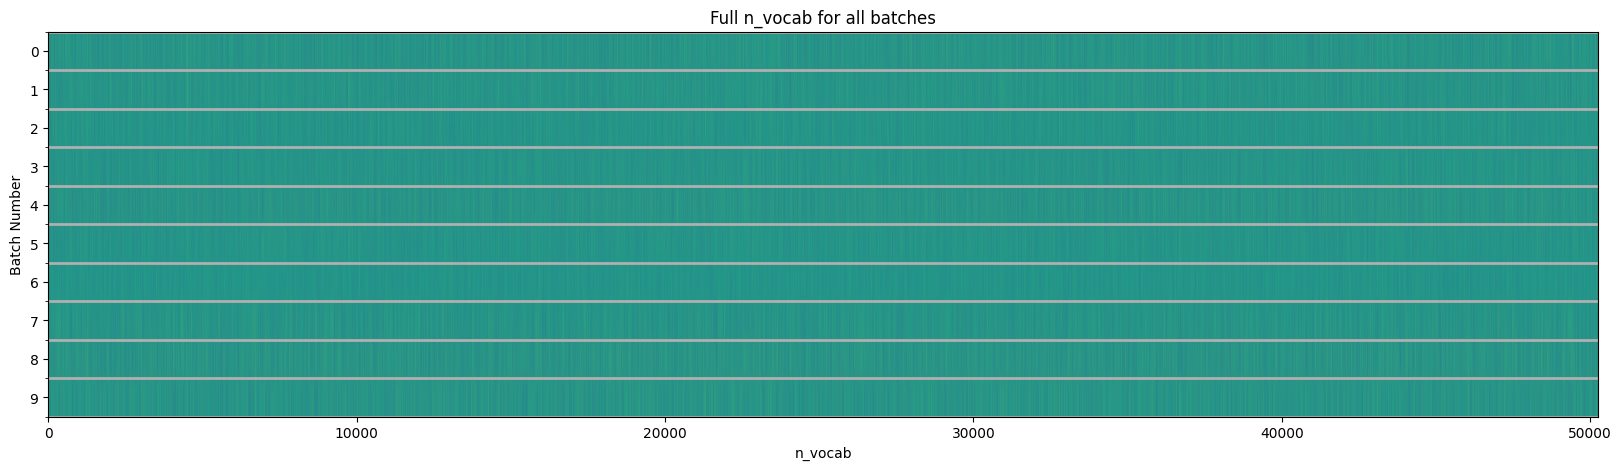

In [ ]:
plt.figure(figsize=(20,5))

plt.imshow(logs.detach(), aspect='auto')

plt.yticks(np.arange(logs.shape[0]))

ax = plt.gca()
ax.set_yticks(np.arange(-0.5, logs.shape[0], 1), minor=True)
ax.grid(which='minor', axis='y', linewidth=2)
ax.grid(which='major', axis='y', alpha=0)

plt.ylabel('Batch Number')
plt.xlabel('n_vocab')

plt.title('Full n_vocab for all batches')

plt.show()

Let's see a close-up.

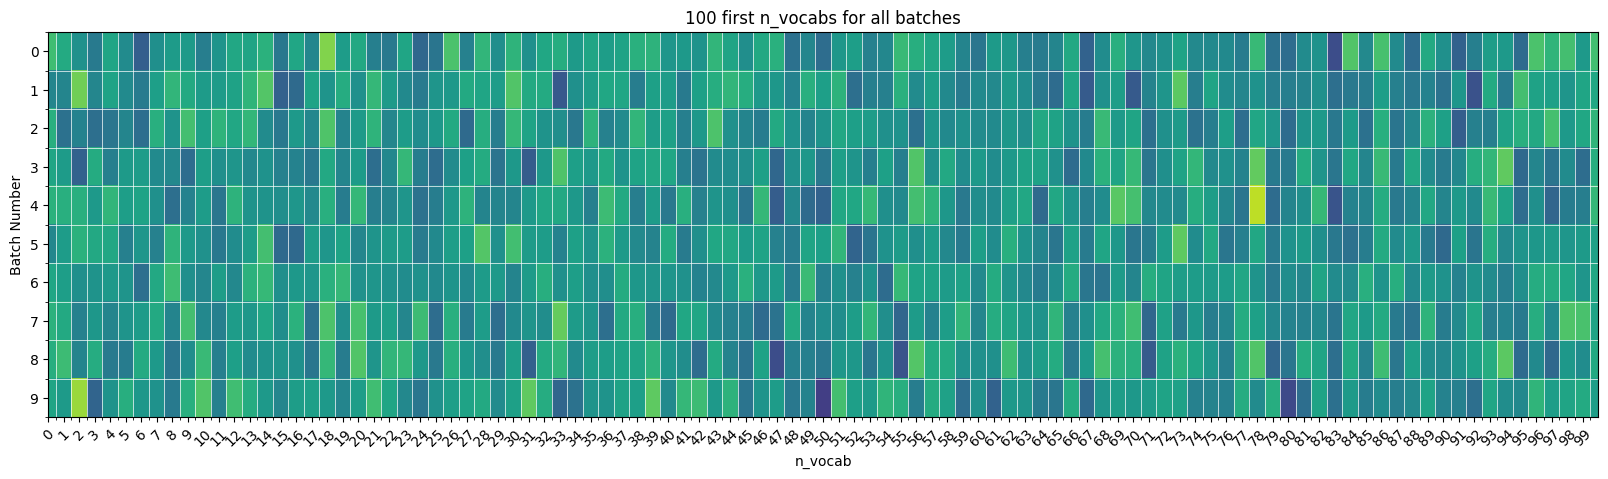

In [ ]:
plt.figure(figsize=(20,5))

plt.imshow(logs.detach(), aspect='auto')

plt.ylabel('Batch Number')
plt.xlabel('n_vocab')

ax = plt.gca()

# batch grid
ax.set_yticks(np.arange(logs.shape[0]))
ax.set_yticks(np.arange(-0.5, logs.shape[0], 1), minor=True)

# vocab grid
ax.set_xticks(np.arange(0,100))
ax.set_xticks(np.arange(-0.5,100,1), minor=True)

# draw grids
ax.grid(which='minor', color='white', linewidth=0.5)

plt.xlim([0,100])
plt.xticks(np.arange(100), rotation=45)

plt.title('100 first n_vocabs for all batches')

plt.show()

As we can see each batch is assembled from `n_vocab` values. It's important to note that even though we got matrix of `[batch_size, n_vocab]` it's actually `[batch_size, last_token (1), n_vocab]` meaning we took last token of `seq_len`. Now, this is important because that means last token (actually all of them but we care about last one) is represented by `n_vocab` length vector. This representation is specifc to given token in terms of the context of that token in whole text (corpus) on which we've trained our model. In other words, this vector of `n_vocab` length is a distribution of "pre-probabilities" of next token, or in oother words logits.

In [ ]:
logits = logs[0].detach()

topk = 100
values, indices = torch.topk(logits, topk)

plt.figure(figsize=(250, 40))

# all logits
plt.plot(logits, 'o', alpha=0.25, markersize = 20)

# top 100 logits
plt.plot(indices, values, 'ro', markersize=20)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

Those are logits for the next token in batch 0, computed from the final position, which contains information from the whole context window. At top we can see 100 highest logits. The next token will be sampled from this distribution, and the top 100 logits are the strongest candidates.

#### F.softmax(logs/temperature, dim = -1)

Changes logits into probabilities. We do softmax on last dimension, i.e. on `n_vocab`.

$$
\text{softmax}_T(x_i)
=
\frac{e^{x_i/T}}
{\sum_{j=1}^{n} e^{x_j/T}}
$$

The higher Temperature

In [ ]:
temps = np.linspace(1, 10, 10)

rand_batch = torch.randint(0, batch_size, (1,)).item()

fig, axs = plt.subplots(10, 1, figsize=(40, 80), sharex=True)

for i, temperature in enumerate(temps):
    probs = F.softmax(logs / temperature, dim=-1)
    p = probs[rand_batch].detach()

    axs[i].plot(p, 'bo', alpha=.5, markersize=8)
    axs[i].set_title(f'Temperature = {temperature:.1f}, batch {rand_batch}', fontsize=20)
    axs[i].set_ylabel('Probability', fontsize=16)

axs[-1].set_xlabel('Vocabulary token index', fontsize=20)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

As we can see, the higher temperature the more tokens are probable of being selected. High Temperature means, that we add more variability into our prediction. We usually use high temperature for more sophisticated models, like generating poems or some other creative tasks, while we use high temperature when we want to be more technical and precise.

#### `torch.multinomial(probs, num_samples = 1)`

This function simply selects 1 sample token with probability defined in probs. Let's only remember that we have 10 batches, so the output should have 10 values, i.e. 10 tokens each for one batch.

In [ ]:
next_tok = torch.multinomial(probs, num_samples = 1)
next_tok

tensor([[32936],
        [49063],
        [40154],
        [ 9214],
        [36479],
        [ 4136],
        [ 5813],
        [  819],
        [13120],
        [22090]])

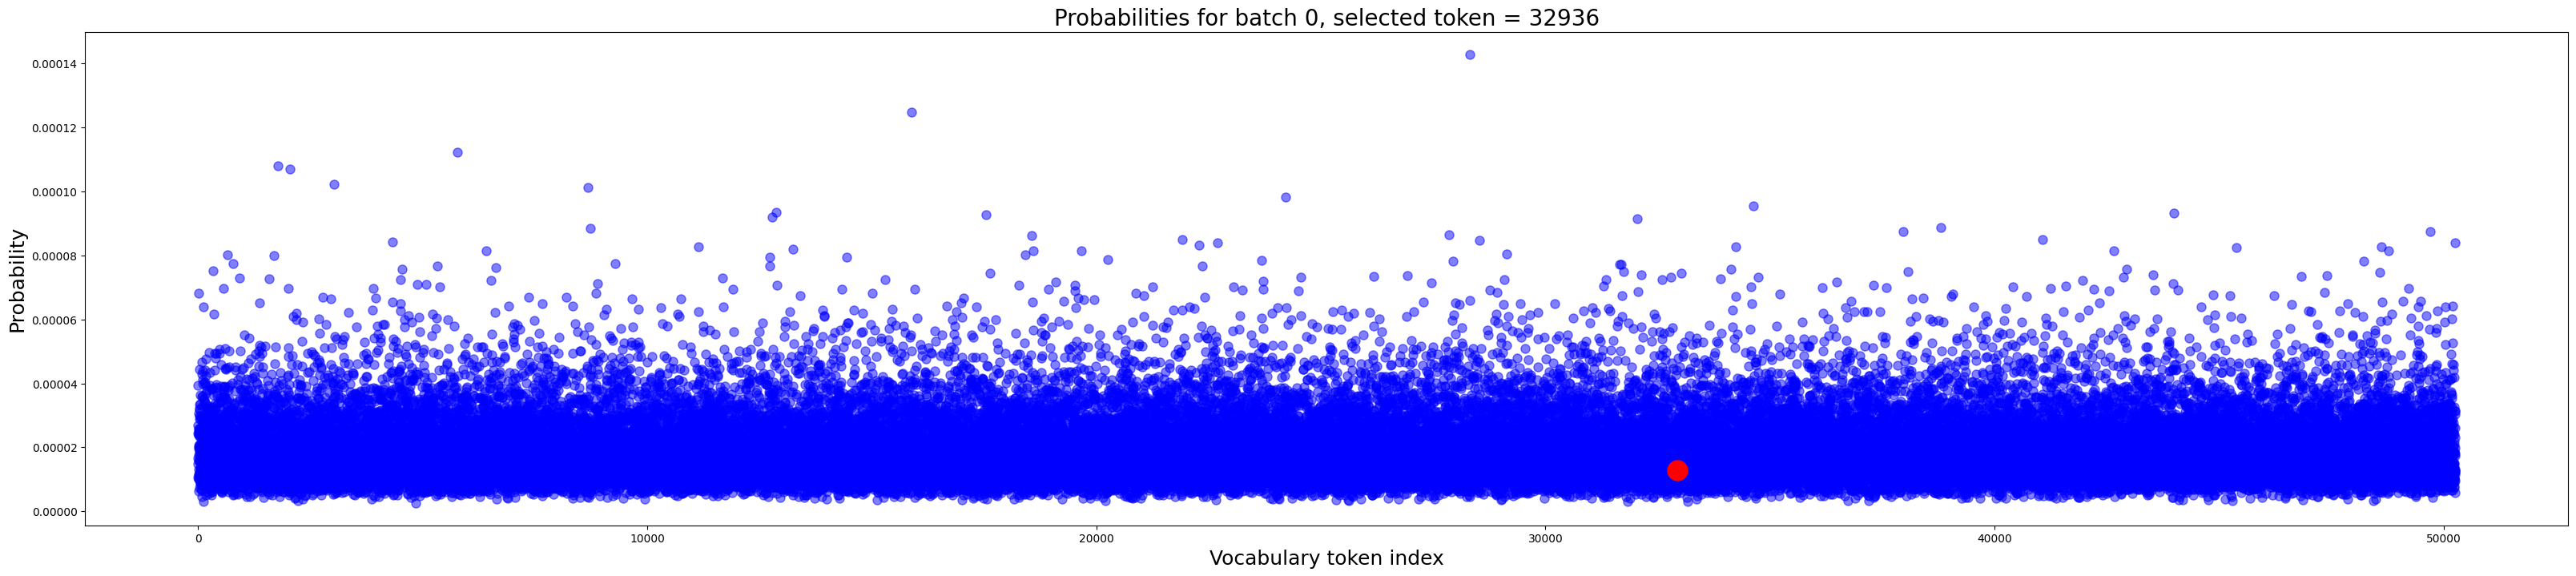

In [ ]:
batch_id = 0

p = probs[batch_id].detach()
selected_token = next_tok[batch_id].item()
selected_prob = p[selected_token]

plt.figure(figsize=(40, 8))

plt.plot(p, 'bo', alpha=.5, markersize=8)
plt.plot(selected_token, selected_prob, 'ro', markersize=18)

plt.title(f'Probabilities for batch {batch_id}, selected token = {selected_token}', fontsize=20)
plt.xlabel('Vocabulary token index', fontsize=18)
plt.ylabel('Probability', fontsize=18)

plt.show()

As we can see choosen token didn't have highest probability. Our Temperature in above plot is 10, due to that the variability is quite high. We can see which token would be selected with Temperature = 1.

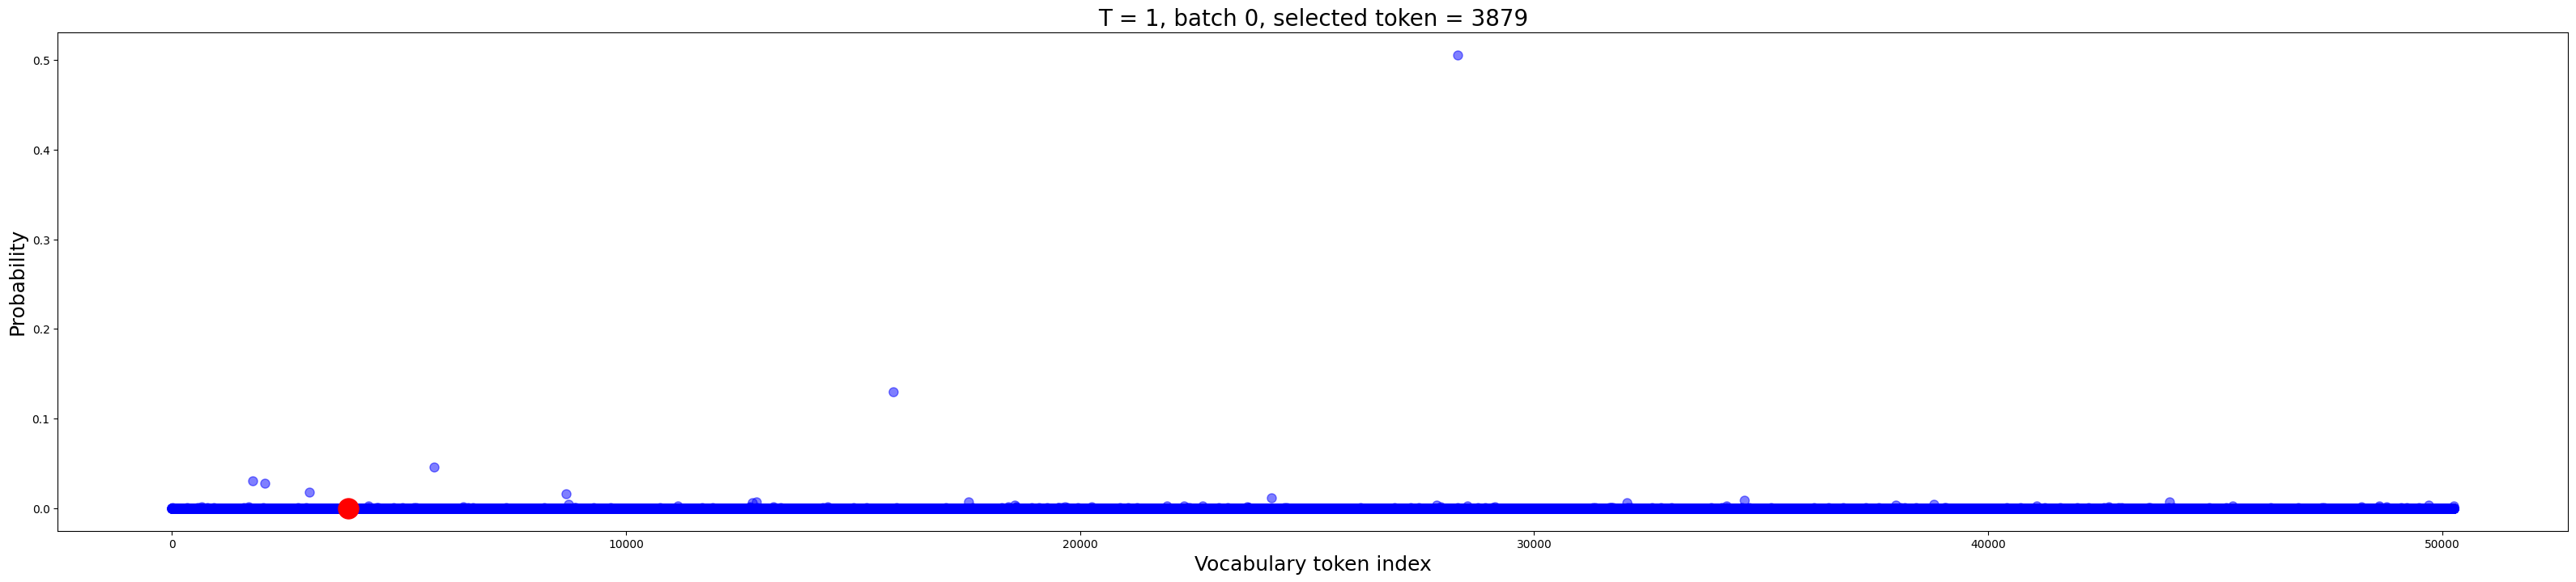

In [ ]:
T = 1

probs = F.softmax(logs / T, dim=-1)

next_tok = torch.multinomial(probs, num_samples=1)

batch_id = 0

p = probs[batch_id].detach()
selected_token = next_tok[batch_id].item()
selected_prob = p[selected_token]

plt.figure(figsize=(40, 8))

plt.plot(p, 'bo', alpha=.5, markersize=8)
plt.plot(selected_token, selected_prob, 'ro', markersize=18)

plt.title(f'T = {T}, batch {batch_id}, selected token = {selected_token}', fontsize=20)
plt.xlabel('Vocabulary token index', fontsize=18)
plt.ylabel('Probability', fontsize=18)

plt.show()

Temperature 1 assures predictability, now selected token obviously has highest probability.

#### `torch.cat((tok_x, next_tok), dim = 1)`

In [ ]:
tok_x.shape

torch.Size([10, 8])

In [ ]:
tok_x = torch.cat((tok_x, next_tok), dim = 1)
tok_x.shape

torch.Size([10, 9])

We can see that `tok_x` before cat has 8 tokens per batch, after `cat` we have 9 tokens per batch. We simply add selected next token to initial `tok_x`. In `generate()` function we specify `n_new_tokens`, meaning we repeat whole generation `n_new_tokens` times, or add same amount tokens to input for each batch. Let's remember that input always has length of `seq_len`, so input window slides 1 token forward each time.

## Text Generation

In [ ]:
model = Model()

text = "I believe I can fly, I believe"
text_encoded = torch.tensor(tokenizer.encode(text)) # We need to have torch tensor
text_encoded = text_encoded.unsqueeze(0) # We need to unsqueeze, so from shape [num_tokens] we're doing [batch_size, num_tokens]
                                         # in our example batch_size = 1 since we have 1 sentence but we need to specify this in dimension
text_encoded.shape

torch.Size([1, 8])

In [ ]:
text_generated_encoded = model.generate(text_encoded, temperature = 2, n_new_tokens = 10)
text_generated_encoded

tensor([[   40,  1975,   314,   460,  6129,    11,   314,  1975,  1592, 46352,
         42707,  4769,  3235, 46212, 41501, 45329, 19042, 37761]])

In [ ]:
text_generated_decoded = tokenizer.decode(text_generated_encoded)
text_generated_decoded

['I believe I can fly, I believe win584 SOS holding mach funkStudio igTokesting']

# Model 1 - Full Transformer Block

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

## Hyperparameters

In [ ]:
seq_len    = 8
batch_size = 10
embed_dim  = 2**6
n_vocab    = tokenizer.vocab_size

## Model

$$
x_0 = E_{\text{tok}}(\text{tok_x}) + E_{\text{pos}}
$$
First representation: token meaning plus position.

$$
\text{residual}_1 = x_0
$$
Save original stream before attention.

$$
h_1 = \mathrm{LN}_1(x_0)
$$
Normalize before attention.

$$
Q = h_1 W_Q,\qquad K = h_1 W_K,\qquad V = h_1 W_V
$$
Create queries, keys, and values.

$$
A = \mathrm{softmax}\left(\frac{QK^\top + M}{\sqrt{d_k}}\right)
$$
Compute causal attention weights, where \(M\) blocks future tokens.

$$
\mathrm{Attention}(h_1) = A V
$$
Mix value vectors using attention weights.

$$
x_1 = \text{residual}_1 + \mathrm{Attention}(h_1)
$$
Add attention output back into the residual stream.

$$
\text{residual}_2 = x_1
$$
Save post-attention stream before MLP.

$$
h_2 = \mathrm{LN}_2(x_1)
$$
Normalize before MLP.

$$
m = W_2\,\mathrm{GELU}(W_1 h_2)
$$
Transform each token independently through the MLP.

$$
x_2 = \text{residual}_2 + m
$$
Add MLP output back into the residual stream.

$$
y = \frac{x_2 W_E^\top + b}{\sqrt{d_{\text{embed}}}}
$$
Project final representations to vocabulary logits using tied embedding weights.

## Attention

In [ ]:
class OneAttentionHead(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()

    self.k  = nn.Linear(embed_dim, embed_dim, bias = False)
    self.q  = nn.Linear(embed_dim, embed_dim, bias = False)
    self.v  = nn.Linear(embed_dim, embed_dim, bias = False)
    self.W0 = nn.Linear(embed_dim, embed_dim)

  def forward(self, x):

    k = self.k(x)
    q = self.q(x)
    v = self.v(x)

    y = F.scaled_dot_product_attention(q,k,v,is_causal=True)
    y = self.W0(y)

    return y

## Model

In [ ]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    self.token_embeddings = nn.Embedding(n_vocab,embed_dim)
    self.posit_embeddings = nn.Embedding(seq_len,embed_dim)

    self.layer_norm_attn = nn.LayerNorm(embed_dim)
    self.attn = OneAttentionHead(embed_dim)

    self.layer_norm_mlp  = nn.LayerNorm(embed_dim)
    self.W1 = nn.Linear(embed_dim, 4*embed_dim)
    self.gelu = nn.GELU()
    self.W2 = nn.Linear(4*embed_dim, embed_dim)

    self.final_layer = nn.Linear(embed_dim, n_vocab)
    self.final_layer.weight = nn.Parameter(self.token_embeddings.weight)

  def forward(self, tok_x):

    token_embeddings = self.token_embeddings(tok_x)                             # [batch_size, num_tokens, embed_dim]
    posit_embeddings = self.posit_embeddings(torch.arange(tok_x.shape[1], device = tok_x.device)) # [num_tokens, embed_dim]

    x = token_embeddings + posit_embeddings # [batch_size, num_tokens, embed_dim]
    residual = x

    ## Attnetion ##
    h = self.layer_norm_attn(x) # [batch_size, num_tokens, embed_dim]
    attn_out = self.attn(h)

    x = residual + attn_out
    ## End of Attention ##

    residual2 = x

    ## MLP ##
    h = self.layer_norm_mlp(x)
    mlp_out = self.W2(self.gelu(self.W1(h)))

    x = residual2 + mlp_out
    ## End of MLP

    y = self.final_layer(x) / np.sqrt(embed_dim)

    return y

  def generate(self, tok_x, temperature, n_new_tokens):

    for _ in range(n_new_tokens):
      x = self(tok_x[:,-seq_len:]) # [batch_size, seq_len, embed_dim]
      logits = x[:,-1,:] # [batch_size, n_vocab]
      probs = F.softmax(logits/temperature, dim = -1)
      next_tok = torch.multinomial(probs, num_samples = 1)
      tok_x = torch.cat((tok_x, next_tok), dim = 1)

    return tok_x

In [ ]:
tok_x = torch.randint(0, n_vocab, (batch_size, seq_len), dtype = torch.long)
tok_x.shape

torch.Size([10, 8])

In [ ]:
model = Model()
out = model.generate(tok_x, temperature = 2, n_new_tokens = 20)
out.shape

torch.Size([10, 28])

## Deconstruction

In [ ]:
tok_x = torch.randint(0, n_vocab, (batch_size, seq_len), dtype = torch.long)
tok_x.shape

torch.Size([10, 8])

### `self.attn = OneAttentionHead(embed_dim)`

This is just attention mechanism we defined in Model 0 wrapped up in a class. The only thing different is that we're using `F.scaled_dot_product_attention(q,k,v,is_causal=True)` which does exact same thing in optimized way.

First let's reconstruct everything that is before `OneAttentionHead()`.

In [ ]:
token_embeddings = nn.Embedding(n_vocab,embed_dim)
posit_embeddings = nn.Embedding(seq_len,embed_dim)

layer_norm_attn = nn.LayerNorm(embed_dim)

Now, we can instantiate `OneAttentionHead()` and see that inside it has same `q, k, v` and `W0` `nn.Linear` matrices.

In [ ]:
attn = OneAttentionHead(embed_dim)
attn

OneAttentionHead(
  (k): Linear(in_features=64, out_features=64, bias=False)
  (q): Linear(in_features=64, out_features=64, bias=False)
  (v): Linear(in_features=64, out_features=64, bias=False)
  (W0): Linear(in_features=64, out_features=64, bias=True)
)

Some, more preprocessing explained in Model_0. Let's note that we save a copy of `x` in `residual` variable. That's derrived directly from Transformer model. We will get to it in next step.

In [ ]:
tok_emb = token_embeddings(tok_x)                                               # [batch_size, num_tokens, embed_dim]
pos_emb = posit_embeddings(torch.arange(tok_x.shape[1], device = tok_x.device)) # [num_tokens, embed_dim]

x = tok_emb + pos_emb # [batch_size, num_tokens, embed_dim]
residual = x

In [ ]:
## Attnetion ##
h        = layer_norm_attn(x) # [batch_size, num_tokens, embed_dim]
attn_out = attn(h)
attn_out.shape

torch.Size([10, 8, 64])

As we can see we get exactly same output as previously, the Attention output.

### `x = residual + attn_out`

This is derrived directly from the Transformer model:

$$
\text{residual}_1 = x_0
$$

$$
h_1 = \mathrm{LN}_1(x_0)
$$

$$\mathrm{Attention} = \text{[Attention Mechanism]}$$

$$x_1 = \text{residual}_1 + \mathrm{Attention}(h_1)$$

We already did `residual = x` let's see its shape.

In [ ]:
residual.shape

torch.Size([10, 8, 64])

We also did

```
h = layer_norm_attn(x)
attn_out = attn(h)
```

last step is:

In [ ]:
x = residual + attn_out
x.shape

torch.Size([10, 8, 64])

So, we have exactly same shape as previously which is quite obvious since we don't do any multiplications. But, why we're doing this? The main idea is that Attention mechanism is for attention, duh... When we want to focus on a book we don't throw out the book to focus better, we direct our attention on the book. We do exactly same thing in Transformer model, we don't replace book or our `x` with `attn_out` we direct our attention on the book, meaning we just add it up.

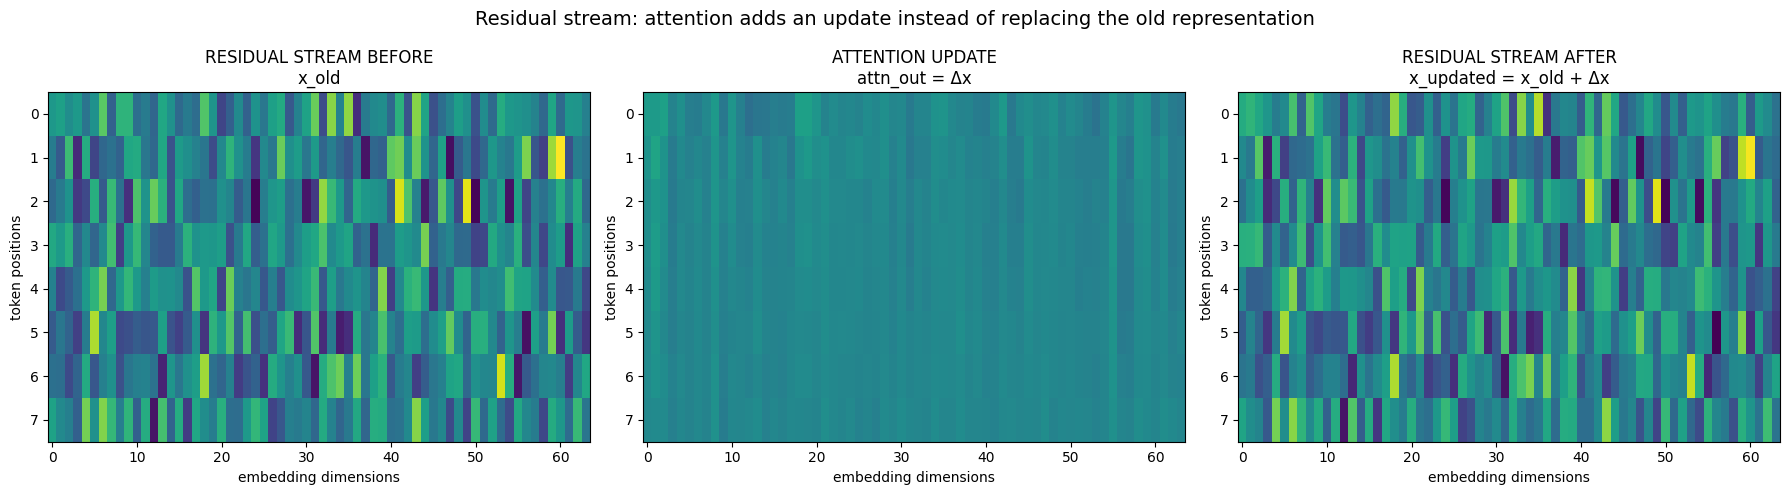

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

rand_batch = torch.randint(0, batch_size, (1,)).item()

residual_img = residual[rand_batch].detach().cpu()
attn_img     = attn_out[rand_batch].detach().cpu()
x_img        = x[rand_batch].detach().cpu()

vmin = min(residual_img.min(), attn_img.min(), x_img.min())
vmax = max(residual_img.max(), attn_img.max(), x_img.max())

axs[0].imshow(residual_img, aspect="auto", vmin=vmin, vmax=vmax)

axs[1].imshow(attn_img, aspect="auto", vmin=vmin, vmax=vmax)

axs[2].imshow(x_img, aspect="auto", vmin=vmin, vmax=vmax)

axs[0].set_title("RESIDUAL STREAM BEFORE\nx_old")

axs[1].set_title("ATTENTION UPDATE\nattn_out = Δx")

axs[2].set_title("RESIDUAL STREAM AFTER\nx_updated = x_old + Δx")

for ax in axs:
    ax.set_xlabel("embedding dimensions")
    ax.set_ylabel("token positions")

plt.suptitle("Residual stream: attention adds an update instead of replacing the old representation", fontsize=14)

plt.tight_layout()
plt.show()

Eventually we get updated `x`.

### Multi-Layer Perceptron MLP

$$
\text{residual}_2 = x_1
$$
Save post-attention stream before MLP.

$$
h_2 = \mathrm{LN}_2(x_1)
$$
Normalize before MLP.

$$
m = W_2\,\mathrm{GELU}(W_1 h_2)
$$
Transform each token independently through the MLP.

$$
x_2 = \text{residual}_2 + m
$$
Add MLP output back into the residual stream.

Here, we will grasp full above transformation. However, if we look closely all lines but one are familiar. `residual2 = x` is copying `x` for the same purpose as in Attention block. `h2 = LN2(x1)` is also same layer normalization as we had in Attention block. Finally, `x2 = residual2 + m` is also exactly the same update of residual stream as in Attention block what we explained in previous step.

The only new thing is `m = W2 GELU(W1 h2)`. First let's do what we need to get there:

In [ ]:
residual2 = x
layer_norm_mlp = nn.LayerNorm(embed_dim)
h2 = layer_norm_mlp(x)

In [ ]:
W1 = nn.Linear(embed_dim, 4*embed_dim)
W2 = nn.Linear(4*embed_dim, embed_dim)
gelu = nn.GELU()

`m = W2 GELU(W1 h2)` is our MLP, on above code cell we can clearly see what is it about. So, it enhances `embed_dim` to `4*embed_dim`, apply `gelu` and eventually shrink it from `4*embed_dim` back to `embed_dim`.

In [ ]:
w1 = W1(h2)
gelu = gelu(w1)
w2 = W2(gelu)

Let's visualize what actually happens here.

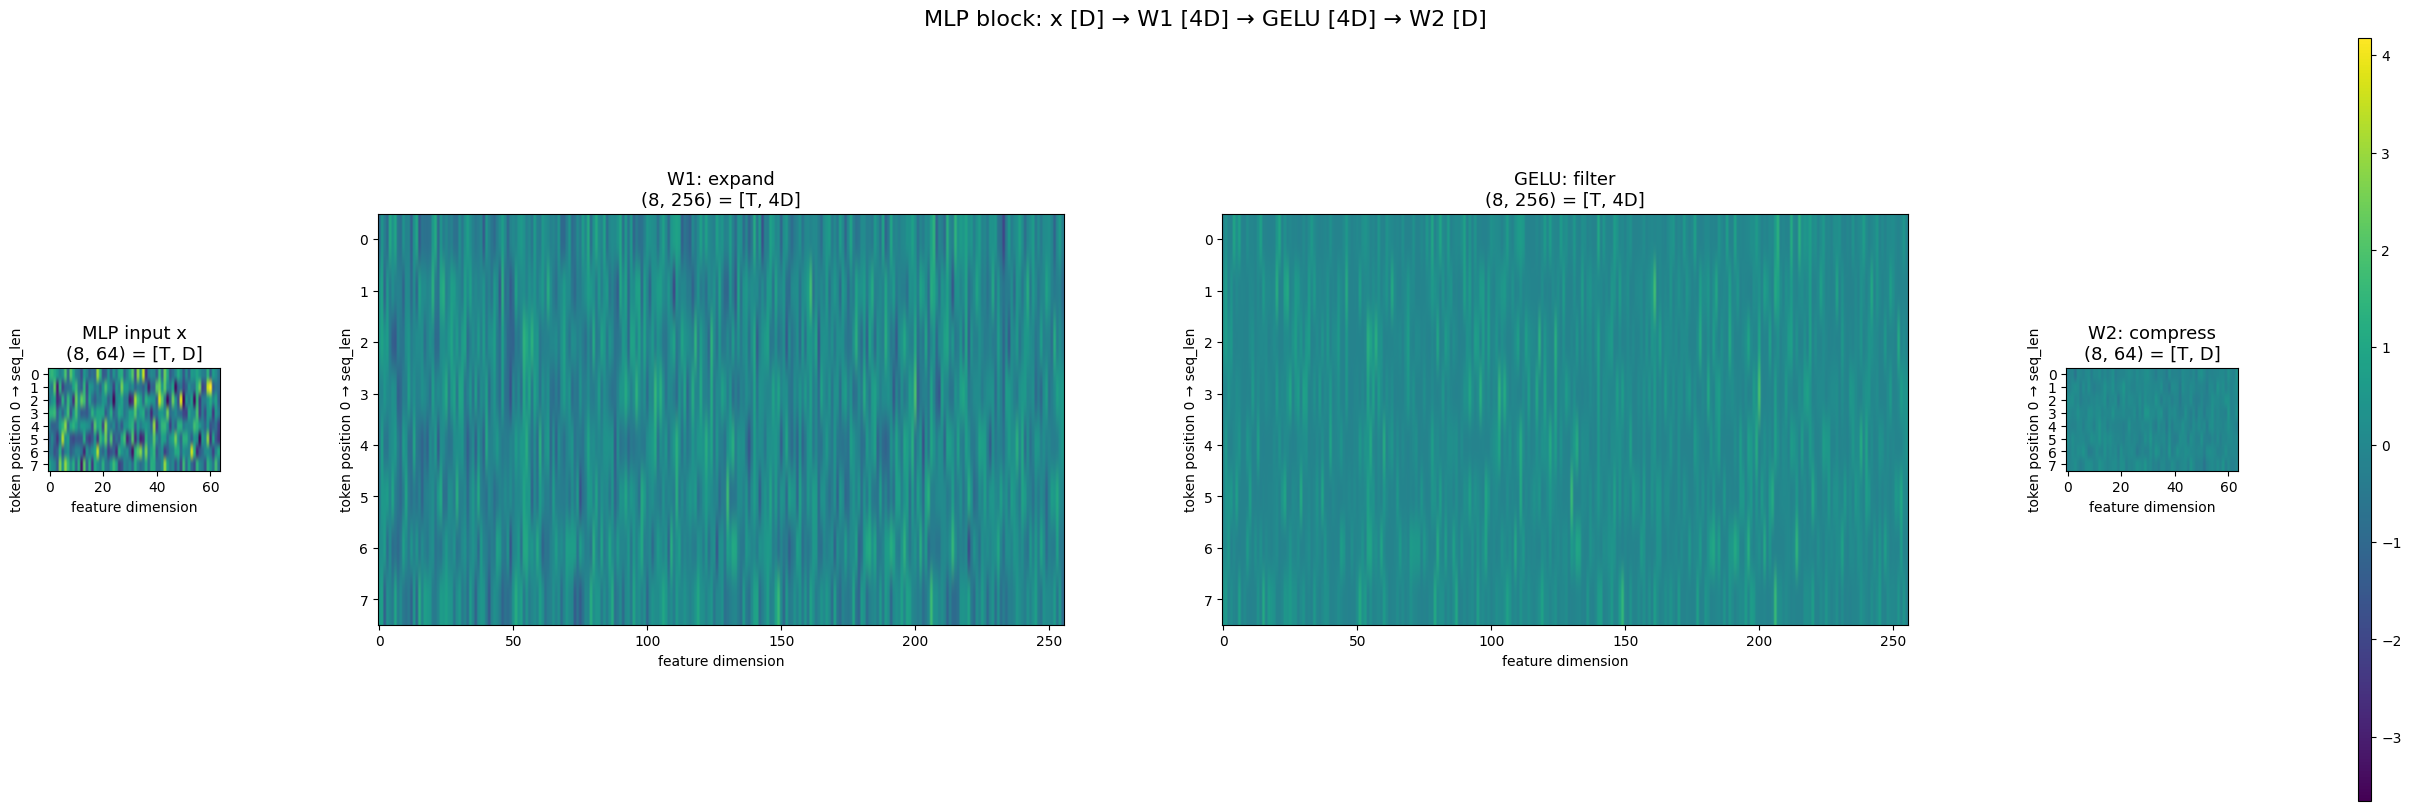

In [ ]:
fig = plt.figure(figsize=(24, 8), constrained_layout=True)

gs = fig.add_gridspec(
    1, 5,
    width_ratios=[1, 4, 4, 1, 0.08],
    wspace=0.25
)

axs = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3]),
]

cax = fig.add_subplot(gs[0, 4])

rand_batch = torch.randint(0, batch_size, (1,)).item()

x_img    = x[rand_batch].detach().cpu()       # [T, D]
w1_img   = w1[rand_batch].detach().cpu()      # [T, 4D]
gelu_img = gelu[rand_batch].detach().cpu()    # [T, 4D]
w2_img   = w2[rand_batch].detach().cpu()      # [T, D]

vmin = min(x_img.min(), w1_img.min(), gelu_img.min(), w2_img.min())
vmax = max(x_img.max(), w1_img.max(), gelu_img.max(), w2_img.max())

plots = [
    (x_img,    f"MLP input x\n{tuple(x_img.shape)} = [T, D]"),
    (w1_img,   f"W1: expand\n{tuple(w1_img.shape)} = [T, 4D]"),
    (gelu_img, f"GELU: filter\n{tuple(gelu_img.shape)} = [T, 4D]"),
    (w2_img,   f"W2: compress\n{tuple(w2_img.shape)} = [T, D]"),
]

for ax, (img, title) in zip(axs, plots):
    im = ax.imshow(img, aspect="auto", vmin=vmin, vmax=vmax)

    T = img.shape[0]
    yticks = np.linspace(0, T - 1, num=min(T, seq_len)).astype(int)
    ylabels = np.linspace(0, seq_len - 1, num=len(yticks)).astype(int)

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("feature dimension")
    ax.set_ylabel("token position 0 → seq_len")
    ax.set_box_aspect(0.6)

fig.colorbar(im, cax=cax)

fig.suptitle(
    "MLP block: x [D] → W1 [4D] → GELU [4D] → W2 [D]",
    fontsize=16
)

plt.show()

Okay, then why we're doing this? The reason is quite simple, by adding new dimensions we want to give "different angles" of view on the represenatation of input, in this example on text. So, our initial `x` has dim of `[num_tokens, embed_dim]` which is `[8, 64]`, then we extend it to `[8, 4*embed_dim = 256]`. Why we do `4*embed_dim` is rather conventional, we could use any other dimensionality extension, this was found the most optimal. But, this still doesn't tell us why we extend dimensionality really, lets look at the bottom plot.

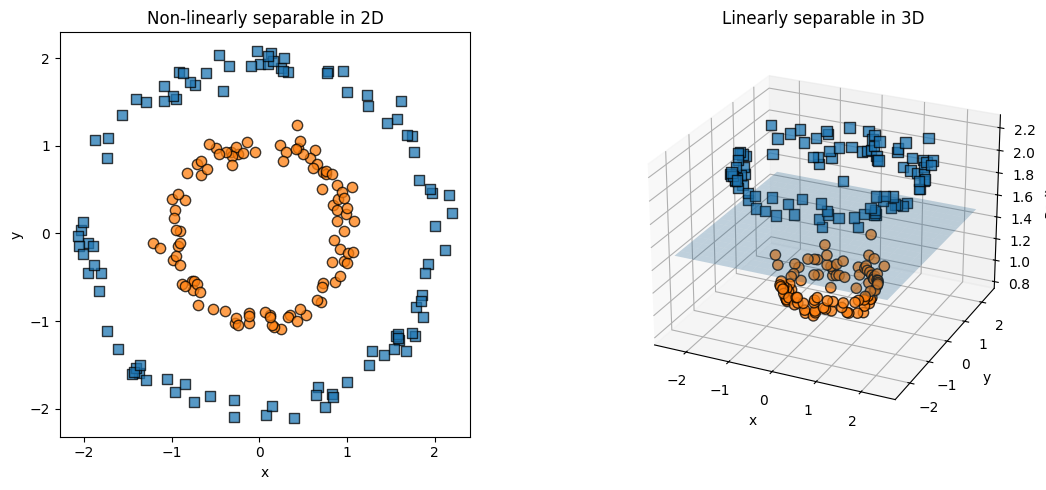

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------
# Generate two noisy rings
# -----------------------
n = 100

theta_inner = np.random.uniform(0, 2*np.pi, n)
theta_outer = np.random.uniform(0, 2*np.pi, n)

r_inner = np.random.normal(1.0, 0.08, n)
r_outer = np.random.normal(2.0, 0.10, n)

x_inner = r_inner * np.cos(theta_inner)
y_inner = r_inner * np.sin(theta_inner)

x_outer = r_outer * np.cos(theta_outer)
y_outer = r_outer * np.sin(theta_outer)

# Third dimension: radius / nonlinear feature
z_inner = np.sqrt(x_inner**2 + y_inner**2)
z_outer = np.sqrt(x_outer**2 + y_outer**2)

# -----------------------
# Plot
# -----------------------
fig = plt.figure(figsize=(12, 5))

# 2D plot
ax1 = fig.add_subplot(1, 2, 1)

ax1.scatter(
    x_outer, y_outer,
    marker="s",
    s=55,
    alpha=0.75,
    edgecolor="black",
    label="Outer class"
)

ax1.scatter(
    x_inner, y_inner,
    marker="o",
    s=55,
    alpha=0.75,
    edgecolor="black",
    label="Inner class"
)

ax1.set_title("Non-linearly separable in 2D")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_aspect("equal")


# 3D plot
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

ax2.scatter(
    x_outer, y_outer, z_outer,
    marker="s",
    s=55,
    alpha=0.75,
    edgecolor="black"
)

ax2.scatter(
    x_inner, y_inner, z_inner,
    marker="o",
    s=55,
    alpha=0.75,
    edgecolor="black"
)

# optional separating plane between classes
xx, yy = np.meshgrid(
    np.linspace(-2.4, 2.4, 20),
    np.linspace(-2.4, 2.4, 20)
)
zz = np.ones_like(xx) * 1.5

ax2.plot_surface(xx, yy, zz, alpha=0.25)

ax2.set_title("Linearly separable in 3D")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("Radius")

ax2.view_init(elev=25, azim=-65)

plt.tight_layout()
plt.show()

By adding 3rd dimension we are able to separate blue dots from orange ones with 1 simple plane. That wouldn't be possible in 2D. That's exactly what we're doing in MLP, we extend to allow model to find other ways to separate patterns.

Okay then we apply `nn.GELU()`. Gelu is an activation function, without that we wouldn't have introduced any non-linearity, and matrix would be just a linear combination of input `x`, or all vectors for each token (all rows for each token in column) would be the same as for input `x` but just in a bigger scale. Adding `nn.GELU()` we filter neurons:

$$
\mathrm{GELU}(x) \approx x \cdot \text{soft gate}(x)
$$

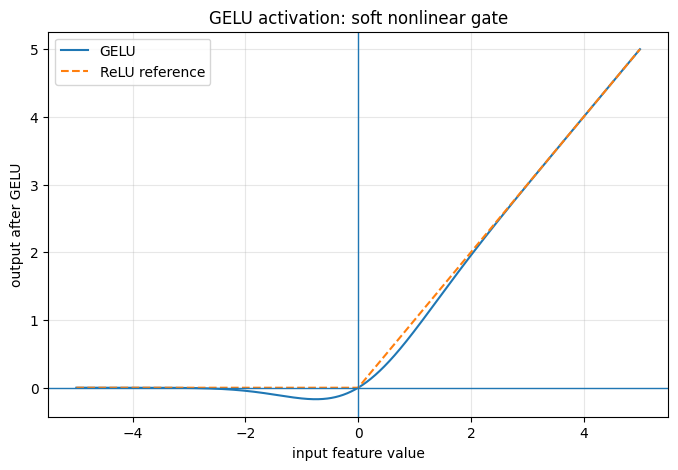

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

z = torch.linspace(-5, 5, 1000)
gelu_z = F.gelu(z)
relu_z = F.relu(z)

plt.figure(figsize=(8, 5))

plt.plot(z, gelu_z, label="GELU")
plt.plot(z, relu_z, linestyle="--", label="ReLU reference")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("GELU activation: soft nonlinear gate")
plt.xlabel("input feature value")
plt.ylabel("output after GELU")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Then we do simple contraction with `W2(x)`, after filtering or after applying `nn.GELU()`. Meaning, we are back into initial shape but with more reliable representation of input `x`.

Eventually, we do the same thing as in the attention mechanism:

$$
x_2 = \text{residual}_2 + m
$$

We add the MLP output back to the pre-MLP residual stream, so the model does not replace the existing representation. It only updates it by adding a learned transformation. Attention updates the representation using information from other tokens, while the MLP updates each token internally by expanding, filtering, and recombining its features. In other words, the MLP helps the model create a richer representation by separating latent patterns that were entangled in the original embedding space.


Let's finalize our model.

In [ ]:
x = w2
y = final_layer(x) / np.sqrt(embed_dim)
y.shape

torch.Size([10, 8, 50257])

And we land in the same shape as in the Model 0, this time with applied MLP.

## Text Generation

In [ ]:
model = Model()

text = 'Love me tender, Love me sweet. Never let'
text_tokenized = tokenizer.encode(text)
text_tokenized = torch.tensor(text_tokenized).unsqueeze(0)
text_tokenized, text_tokenized.shape

(tensor([[18565,   502, 15403,    11,  5896,   502,  6029,    13,  7236,  1309]]),
 torch.Size([1, 10]))

In [ ]:
text_generated_encoded = model.generate(text_tokenized, temperature = 2, n_new_tokens = 20)
text_generated_encoded

tensor([[18565,   502, 15403,    11,  5896,   502,  6029,    13,  7236,  1309,
         15781,  6410, 40149,  5891, 38712, 38712, 23707, 46390, 19241, 39116,
         11166, 29137, 28466, 25593, 38192, 30705, 30310, 38689,  4376,  6806]])

In [ ]:
text_generated_decoded = tokenizer.decode(text_generated_encoded)
text_generated_decoded

['Love me tender, Love me sweet. Never let Aerrastructure482 fellow constellation constellation housed lum bacterishersihadapproved Chimbolt unsettlingasley Vega sealing raisedarity']

# Model 2 - Multiple Transformer Blocks

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import GPT2Tokenizer

import numpy as np

import matplotlib.pyplot as plt

## Hyperparameters

In [ ]:
batch_size = 10
seq_len    = 8
embed_dim  = 2**6

n_transformer_blocks = 12

tokenizer  = GPT2Tokenizer.from_pretrained('gpt2')
n_vocab    = tokenizer.vocab_size

## Attention Head

In [ ]:
class OneHeadAttention(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()

    self.k = nn.Linear(embed_dim, embed_dim, bias = False)
    self.q = nn.Linear(embed_dim, embed_dim, bias = False)
    self.v = nn.Linear(embed_dim, embed_dim, bias = False)

    self.W0 = nn.Linear(embed_dim, embed_dim)

  def forward(self, x):

    k = self.k(x)
    q = self.q(x)
    v = self.v(x)
    y = F.scaled_dot_product_attention(q,k,v,is_causal=True)
    y = self.W0(y)

    return y

In [ ]:
x = torch.randn(batch_size, seq_len, embed_dim)

h = OneHeadAttention(embed_dim)
attn_out = h(x)
attn_out.shape

torch.Size([10, 8, 64])

## Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()

    self.layer_norm_attn = nn.LayerNorm(embed_dim)
    self.attn            = OneHeadAttention(embed_dim)

    self.layer_norm_mlp  = nn.LayerNorm(embed_dim)
    self.W1              = nn.Linear(embed_dim, 4*embed_dim)
    self.gelu            = nn.GELU()
    self.W2              = nn.Linear(4*embed_dim, embed_dim)


  def forward(self, x):

    # ------- attention sublayer ------ #
    x = x + self.attn(self.layer_norm_attn(x))
    # --------------------------------- #

    # ------- MLP sublayer ------------ #
    y = x + self.W2(self.gelu(self.W1(self.layer_norm_mlp(x))))
    # --------------------------------- #

    return y

In [ ]:
t = TransformerBlock(embed_dim)
y = t(x)
y.shape

torch.Size([10, 8, 64])

Let's Test

## Model

In [ ]:
class Model(nn.Module):
  def __init__(self, n_transformer_blocks, embed_dim):
    super().__init__()

    self.token_embeddings = nn.Embedding(n_vocab, embed_dim)
    self.posit_embeddings = nn.Embedding(seq_len, embed_dim)

    # NEW
    self.transformer_blocks = nn.Sequential(*[TransformerBlock(embed_dim) for _ in range(n_transformer_blocks)])

    self.final_layer_norm = nn.LayerNorm(embed_dim)
    self.final_layer = nn.Linear(embed_dim, n_vocab)
    self.final_layer.weight = nn.Parameter(self.token_embeddings.weight)

  def forward(self, tok_x):

    tok_em = self.token_embeddings(tok_x) # [batch_size, tok_nums, embed_dim]
    pos_em = self.posit_embeddings(torch.arange(tok_x.shape[-1])) # [batch_size, tok_nums, embed_dim]
    x = tok_em + pos_em # [batch_size, tok_nums, embed_dim]

    ## transformer blocks ##
    x = self.transformer_blocks(x)

    # final layer
    x = self.final_layer_norm(x)
    x = self.final_layer(x)

    return x

  def generate(self, tok_x, temperature, n_new_tokens):

    for _ in range(n_new_tokens):
      x        = self(tok_x[:,-seq_len:]) # [batch_size, seq_len, embed_dim]
      logs     = x[:,-1,:] # [batch_size, embed_dim]
      probs    = F.softmax(logs/temperature, dim = -1) # [batch_size, embed_dim]
      next_tok = torch.multinomial(probs, num_samples = 1)
      tok_x    = torch.cat((tok_x, next_tok), dim = 1)

    return tok_x

In [ ]:
tok_x = torch.randint(0, n_vocab,(batch_size, seq_len), dtype = torch.long)
tok_x

tensor([[35866,  1486,  1378, 16734,  2533, 26484, 49575, 44902],
        [17840, 41220, 44963,   198, 16661, 42962, 10222, 46807],
        [21451,  9650,  2756,  7437, 47233,  5501, 36037, 18829],
        [ 5158, 38483, 42854, 38528, 48046, 44976, 17833, 19177],
        [28296, 10740,  8786, 48327, 44245,  8196, 40478,   715],
        [32180, 16916, 14742, 33789, 16667, 31673, 11423, 23579],
        [21194,  5455,  1922, 22907, 44297, 47622, 32293, 41165],
        [13216,  7716, 40882, 23914,  8734, 35400, 11408,  3169],
        [18985, 10970, 14182, 39497, 42500, 31076, 43846, 42990],
        [13817, 15723, 31117, 35625,  3068, 27031, 38138, 47975]])

In [ ]:
llm = Model(n_transformer_blocks, embed_dim)
llm

Model(
  (token_embeddings): Embedding(50257, 64)
  (posit_embeddings): Embedding(8, 64)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (layer_norm_attn): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): OneHeadAttention(
        (k): Linear(in_features=64, out_features=64, bias=False)
        (q): Linear(in_features=64, out_features=64, bias=False)
        (v): Linear(in_features=64, out_features=64, bias=False)
        (W0): Linear(in_features=64, out_features=64, bias=True)
      )
      (layer_norm_mlp): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (W1): Linear(in_features=64, out_features=256, bias=True)
      (gelu): GELU(approximate='none')
      (W2): Linear(in_features=256, out_features=64, bias=True)
    )
    (1): TransformerBlock(
      (layer_norm_attn): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): OneHeadAttention(
        (k): Linear(in_features=64, out_features=64, bias=False)
        (q): Linea

In [ ]:
llm.transformer_blocks[2]

TransformerBlock(
  (layer_norm_attn): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attn): OneHeadAttention(
    (k): Linear(in_features=64, out_features=64, bias=False)
    (q): Linear(in_features=64, out_features=64, bias=False)
    (v): Linear(in_features=64, out_features=64, bias=False)
    (W0): Linear(in_features=64, out_features=64, bias=True)
  )
  (layer_norm_mlp): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (W1): Linear(in_features=64, out_features=256, bias=True)
  (gelu): GELU(approximate='none')
  (W2): Linear(in_features=256, out_features=64, bias=True)
)

In [ ]:
llm.transformer_blocks[4].attn

OneHeadAttention(
  (k): Linear(in_features=64, out_features=64, bias=False)
  (q): Linear(in_features=64, out_features=64, bias=False)
  (v): Linear(in_features=64, out_features=64, bias=False)
  (W0): Linear(in_features=64, out_features=64, bias=True)
)

## Text Generation

In [ ]:
tok_gen_enc = llm.generate(tok_x, temperature = 3, n_new_tokens = 20)
tok_gen_dec = tokenizer.decode(tok_gen_enc)
tok_gen_dec

['enic design:// Beltirm Signal looted Playstation Mankind Mankind Mankind Mankind Mankind Mankind pressure pressure pressure pressure pressure pressure pressure pressure pressure pressure pressure pressure pressure pressure',
 ' troubled diploma Styles\ninis degrade spotsTylerTylerTylerTylerTylerTyler TRANS moaning moaning moaning moaning moaning moaning moaning moaning moaning moaning moaning moaning moaning moaning',
 ' blatotion priceAmerican 502 EachCPUwolf communion communion communion communion communion communion communion communion concurrently concurrently concurrently concurrently concurrently concurrently concurrently concurrently concurrentlyydiaydiaLight',
 ' spoke Behavioralphysicalsclbringerenforcementpires huntertakerMe routed routed routed widen tired329329329329329329329329329329329329329',
 '1984 Gear writers assassinateAid screamcemicittmilitary resisting resistingwrawrawrawrawrawrawrawrawrawrawrawrawrawrawrawra Brill',
 'Operation indicator ambitious tits tommemor

## Deconstruction

In [ ]:
tok_em = token_embeddings(tok_x) # [batch_size, tok_nums, embed_dim]
pos_em = posit_embeddings(torch.arange(tok_x.shape[-1])) # [batch_size, tok_nums, embed_dim]
x = tok_em + pos_em # [batch_size, tok_nums, embed_dim]

### `TransformerBlock()`

We simply wrapped up Attention and MLP in one class. No new things here.

In [ ]:
x = torch.randn(batch_size, seq_len, embed_dim)
t = TransformerBlock(embed_dim)
y = t(x)
y.shape

torch.Size([10, 8, 64])

### n transformer blocks

Here we do 12 transformers implemented sequentially.

In [ ]:
token_embeddings = nn.Embedding(n_vocab, embed_dim)
posit_embeddings = nn.Embedding(seq_len, embed_dim)

# NEW
transformer_blocks = nn.Sequential(*[TransformerBlock(embed_dim) for _ in range(n_transformer_blocks)])

Here we unpack each transformer and wrap it up in `nn.Sequential`. However, for simplicity let's implement `transformer_blocks` manually.

In [ ]:
transformer_blocks = [*[TransformerBlock(embed_dim) for _ in range(n_transformer_blocks)]]
transformer_blocks

[TransformerBlock(
   (layer_norm_attn): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
   (attn): OneHeadAttention(
     (k): Linear(in_features=64, out_features=64, bias=False)
     (q): Linear(in_features=64, out_features=64, bias=False)
     (v): Linear(in_features=64, out_features=64, bias=False)
     (W0): Linear(in_features=64, out_features=64, bias=True)
   )
   (layer_norm_mlp): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
   (W1): Linear(in_features=64, out_features=256, bias=True)
   (gelu): GELU(approximate='none')
   (W2): Linear(in_features=256, out_features=64, bias=True)
 ),
 TransformerBlock(
   (layer_norm_attn): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
   (attn): OneHeadAttention(
     (k): Linear(in_features=64, out_features=64, bias=False)
     (q): Linear(in_features=64, out_features=64, bias=False)
     (v): Linear(in_features=64, out_features=64, bias=False)
     (W0): Linear(in_features=64, out_features=64, bias=True)
   )
   (layer_no

In [ ]:
len(transformer_blocks)

12

We have 12 transformer blocks as we specified in `n_transformer_blocks`. Then we place all of them in `nn.Sequential()` meaning we process all transformers sequentially, 1st Transformers output is input to 2nd Transformer, 2nd Transformers output is input to 3rd Transformer, etc.

Okay we have 12 transformer blocks layed out sequentially, but why? First lets do Model preprocessing.

In [ ]:
tok_em = token_embeddings(tok_x) # [batch_size, tok_nums, embed_dim]
pos_em = posit_embeddings(torch.arange(tok_x.shape[-1])) # [batch_size, tok_nums, embed_dim]
x = tok_em + pos_em # [batch_size, tok_nums, embed_dim]
x.shape

torch.Size([10, 8, 64])

Now, instead of using expression from model, i.e. instead of `x = self.transformer_blocks(x)` lets do manual sequential implemented bellow to see how one batch (one input text) changes during each transformer block.

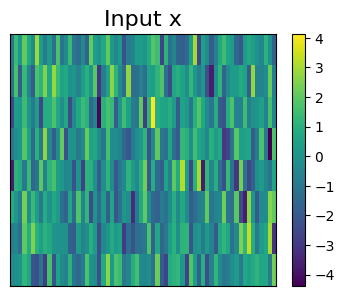

In [ ]:
import matplotlib.pyplot as plt

# x shape: [batch_size, seq_len, embed_dim]

input_x = x.detach().cpu()

vmin = input_x[0].min().item()
vmax = input_x[0].max().item()

fig, ax = plt.subplots(figsize=(4, 3))

im = ax.imshow(input_x[0], aspect="auto", vmin=vmin, vmax=vmax)
ax.set_title("Input x", fontsize=16)
ax.set_xticks([])
ax.set_yticks([])


fig.subplots_adjust(
    left=0.05,
    right=0.88,
    bottom=0.06,
    top=0.90
)

fig.colorbar(im, ax=ax)

plt.show()

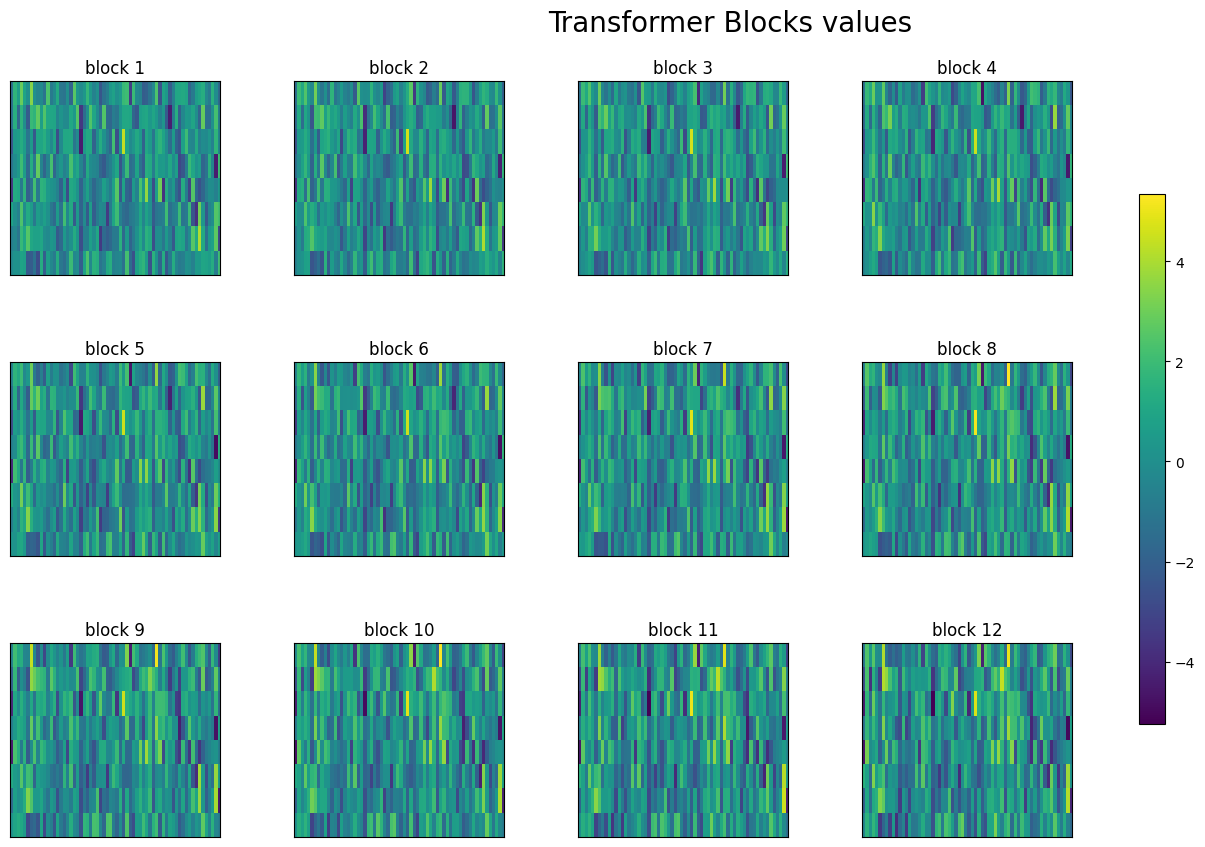

In [ ]:
import matplotlib.pyplot as plt

# x shape: [batch_size, seq_len, embed_dim]

acts = []

for i in range(n_transformer_blocks):
    x = transformer_blocks[i](x)
    acts.append(x.detach().cpu())  # only block outputs

# wspólna skala kolorów dla bloków
vmin = min(a[0].min().item() for a in acts)
vmax = max(a[0].max().item() for a in acts)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        acts[i][0],
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"block {i+1}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Transformer Blocks values", fontsize=20, y=0.98)

fig.subplots_adjust(
    left=0.05,
    right=0.88,
    bottom=0.06,
    top=0.90,
    wspace=0.35,
    hspace=0.45
)

fig.colorbar(im, ax=axes, shrink=0.7)

plt.show()

And changes between blocks.

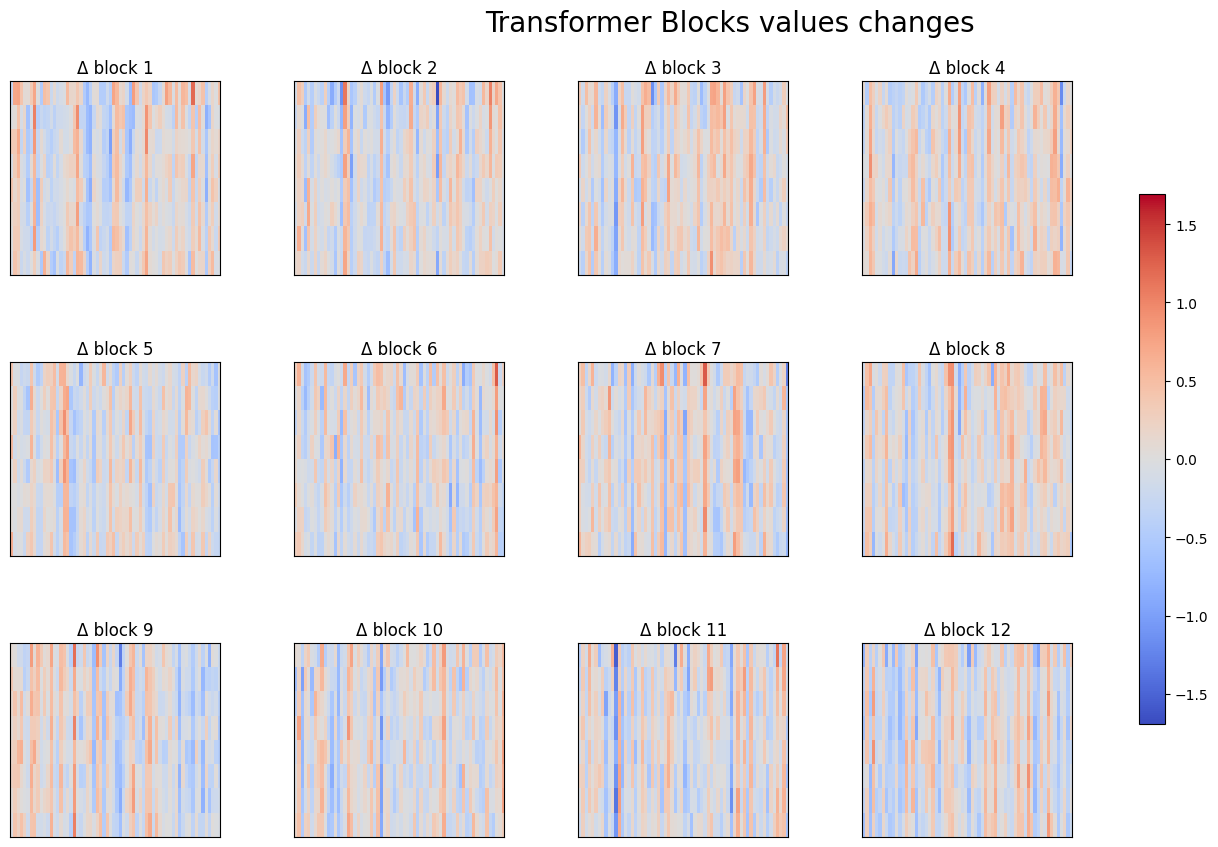

In [ ]:
import matplotlib.pyplot as plt

acts = [x.detach().cpu()]

for block in transformer_blocks:
    x = block(x)
    acts.append(x.detach().cpu())

deltas = [acts[i] - acts[i-1] for i in range(1, len(acts))]

vmax = max(d[0].abs().max().item() for d in deltas)
vmin = -vmax

fig, axes = plt.subplots(3, 4, figsize=(16, 9))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        deltas[i][0],
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="coolwarm"
    )
    ax.set_title(f"Δ block {i+1}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Transformer Blocks values changes", fontsize=20, y=0.98)

fig.subplots_adjust(
    left=0.05,
    right=0.88,
    bottom=0.06,
    top=0.90,
    wspace=0.35,
    hspace=0.45
)

fig.colorbar(im, ax=axes, shrink=0.7)

plt.show()

Each transformer block changes the hidden representation only slightly, because the model uses residual connections, but the accumulated effect across 12 blocks gradually refines the token representations.

# Model 3 - Multi Head Attention

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from transformers import GPT2Tokenizer

## Hyperparameters

In [ ]:
batch_size = 10
seq_len    = 8
embed_dim  = 2**8
num_heads  = 8 # NEW
tokenizer  = GPT2Tokenizer.from_pretrained('GPT2')
n_transformer_blocks = 12
n_vocab    = tokenizer.vocab_size

## Multi Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_dim, num_heads):
    super().__init__()

    assert embed_dim % num_heads == 0

    self.num_heads = num_heads
    self.head_dim  = embed_dim // num_heads

    self.q = nn.Linear(embed_dim, embed_dim, bias=False)
    self.k = nn.Linear(embed_dim, embed_dim, bias=False)
    self.v = nn.Linear(embed_dim, embed_dim, bias=False)

    self.W0 = nn.Linear(embed_dim, embed_dim, bias=False)

  def forward(self, x):
    batch_size, tok_nums, embed_dim = x.shape

    q = self.q(x)  # [batch_size,tok_nums,embed_dim]
    k = self.k(x)  # [batch_size,tok_nums,embed_dim]
    v = self.v(x)  # [batch_size,tok_nums,embed_dim]

    # [batch_size,tok_nums,embed_dim] -> [batch_size,tok_nums,num_heads,head_dim] -> [batch_size,num_heads,tok_nums,head_dim]
    # embed_dim = num_heads x head_dim
    q = q.view(batch_size, tok_nums, self.num_heads, self.head_dim).transpose(1, 2)
    k = k.view(batch_size, tok_nums, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(batch_size, tok_nums, self.num_heads, self.head_dim).transpose(1, 2)

    ### ATTENTION - We can use:
    #   y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # [batch_size,num_heads,tok_nums,head_dim]
    ###

    # [batch_size,num_heads,tok_nums,head_dim] @ [batch_size,num_heads,head_dim,tok_nums] -> [batch_size,num_heads,tok_nums,tok_nums]
    attn_scores = q @ k.transpose(-2, -1)

    # scaled dot-product attention
    attn_scores = attn_scores / (self.head_dim ** 0.5) # [batch_size,num_heads,tok_nums,tok_nums]

    # causal mask
    mask = torch.tril(torch.ones(tok_nums, tok_nums, device=x.device)).bool() # [tok_nums,tok_nums]
    attn_scores = attn_scores.masked_fill(mask == False, float("-inf")) # [batch_size,num_heads,tok_nums,tok_nums]

    # attention probabilities
    attn_weights = F.softmax(attn_scores, dim=-1) # [batch_size,num_heads,tok_nums,tok_nums]

    # [batch_size,num_heads,tok_nums,tok_nums] @ [batch_size,num_heads,tok_nums,head_dim] -> [batch_size,num_heads,tok_nums,head_dim]
    y = attn_weights @ v # [batch_size,num_heads,tok_nums,head_dim]

    ### END ATTENTION



    # [batch_size,num_heads,tok_nums,head_dim] -> [batch_size,tok_nums,num_heads,head_dim] -> [batch_size,tok_nums,embed_dim]
    y = y.transpose(1, 2).contiguous().view(batch_size, tok_nums, embed_dim)

    y = self.W0(y)  # [batch_size,tok_nums,embed_dim]

    return y

In [ ]:
x = torch.randn(batch_size, seq_len, embed_dim)

oha = MultiHeadAttention(embed_dim, num_heads)
attn = oha(x)
attn.shape

torch.Size([10, 8, 256])

## Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, embed_dim, num_heads):
    super().__init__()

    self.layer_norm_attn = nn.LayerNorm(embed_dim)
    self.attn            = MultiHeadAttention(embed_dim, num_heads)

    self.layer_norm_mlp  = nn.LayerNorm(embed_dim)
    self.W1              = nn.Linear(embed_dim, 4 * embed_dim)
    self.gelu            = nn.GELU()
    self.W2              = nn.Linear(4 * embed_dim, embed_dim)

  def forward(self, x):
    x = x + self.attn(self.layer_norm_attn(x))

    y = self.layer_norm_mlp(x)
    y = self.W1(y)
    y = self.gelu(y)
    y = self.W2(y)

    x = x + y

    return x

In [ ]:
t = TransformerBlock(embed_dim, num_heads)
y = t(x)
y.shape

torch.Size([10, 8, 256])

## Model

In [ ]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.seq_len = seq_len
    self.token_embeddings = nn.Embedding(n_vocab, embed_dim)
    self.posit_embeddings = nn.Embedding(seq_len, embed_dim)
    self.transformer_blocks = nn.Sequential(*[TransformerBlock(embed_dim, num_heads) for _ in range(n_transformer_blocks)])
    self.final_layer_norm = nn.LayerNorm(embed_dim)
    self.final_layer = nn.Linear(embed_dim, n_vocab, bias=False)
    self.final_layer.weight = self.token_embeddings.weight

  def forward(self, tok_x):
    B, T = tok_x.shape # [batch_size, tok_nums]
    tok_emb = self.token_embeddings(tok_x) # [batch_size, tok_nums, embed_dim]
    pos_idx = torch.arange(T, device=tok_x.device) # [tok_nums]
    pos_emb = self.posit_embeddings(pos_idx) # [tok_nums, embed_dim]
    x = tok_emb + pos_emb # [batch_size, tok_nums, embed_dim]
    x = self.transformer_blocks(x) # [batch_size, tok_nums, embed_dim]
    x = self.final_layer_norm(x) # [batch_size, tok_nums, embed_dim]
    x = self.final_layer(x) # [batch_size, tok_nums, n_vocab]
    return x

  @torch.no_grad()
  def generate(self, tok_x, temperature, n_new_tokens):
    for _ in range(n_new_tokens):
      tok_x_cond = tok_x[:, -self.seq_len:] # [batch_size, <=seq_len]
      x = self(tok_x_cond) # [batch_size, tok_nums, n_vocab]
      logs = x[:, -1, :] # [batch_size, n_vocab]
      probs = F.softmax(logs / temperature, dim=-1) # [batch_size, n_vocab]
      next_tok = torch.multinomial(probs, num_samples=1) # [batch_size, 1]
      tok_x = torch.cat((tok_x, next_tok), dim=1) # [batch_size, tok_nums+1]
    return tok_x

In [ ]:
tok_x = torch.randint(0, n_vocab,(batch_size, seq_len), dtype = torch.long)
llm = Model()

## Text Generation

In [ ]:
tok_gen_enc = llm.generate(tok_x, temperature = 3, n_new_tokens = 20)
tok_gen_dec = tokenizer.decode(tok_gen_enc)
tok_gen_dec

[' insecurity AlbuquerqueuniaMusic smokes (-oulavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavoriteavorite',
 'lict Dwar Chaigureasers crocod Needless289289289289289289289289289289289289289289289289289289289289289',
 ' Marijuanaksh bilateralagonal destroy proposed pose motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists motorists',
 ' dependency interacted rendered reveals shallowchlor plentyoranoranoranoranoranoranoranoranoranoranoranoranoranoranoranoranoranoranoranoranoran',
 ' 21 pel thinksisodes armoured fastermiteWoWoWoWoWoWoWoWoWoWoWoWoWoWoWoWoWoWoWoWoWo',
 ' stem populartenessン TMZ Destination listingsissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissanceissance'

## Deconstruction

### `MultiHeadAttention()`

In [ ]:
batch_size = 10
seq_len    = 8
embed_dim  = 2**8
num_heads  = 8 # NEW
tokenizer  = GPT2Tokenizer.from_pretrained('GPT2')
n_transformer_blocks = 12
n_vocab    = tokenizer.vocab_size

In [ ]:
# assert embed_dim % num_heads == 0
head_dim  = embed_dim // num_heads

q = nn.Linear(embed_dim, embed_dim, bias=False)
k = nn.Linear(embed_dim, embed_dim, bias=False)
v = nn.Linear(embed_dim, embed_dim, bias=False)

W0 = nn.Linear(embed_dim, embed_dim, bias=False)

In [ ]:
batch_size, tok_nums, embed_dim = x.shape

q = q(x)  # [batch_size,tok_nums,embed_dim]
k = k(x)  # [batch_size,tok_nums,embed_dim]
v = v(x)  # [batch_size,tok_nums,embed_dim]

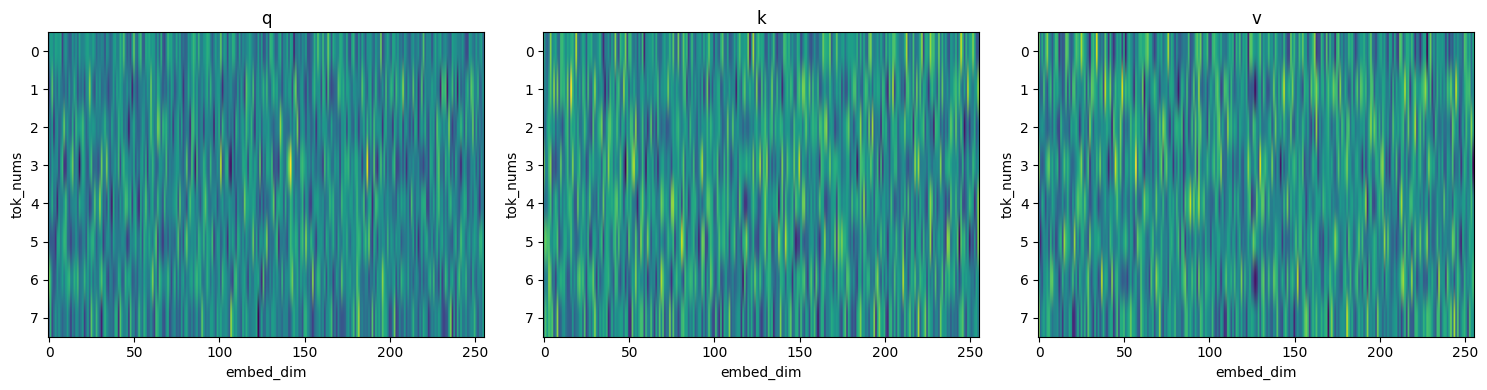

In [ ]:
batch_idx = torch.randint(0, q.shape[0], (1,)).item()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].imshow(q[batch_idx].detach().cpu(), aspect="auto") # [tok_nums,embed_dim]
ax[0].set_title("q")
ax[0].set_xlabel("embed_dim")
ax[0].set_ylabel("tok_nums")

ax[1].imshow(k[batch_idx].detach().cpu(), aspect="auto") # [tok_nums,embed_dim]
ax[1].set_title("k")
ax[1].set_xlabel("embed_dim")
ax[1].set_ylabel("tok_nums")

ax[2].imshow(v[batch_idx].detach().cpu(), aspect="auto") # [tok_nums,embed_dim]
ax[2].set_title("v")
ax[2].set_xlabel("embed_dim")
ax[2].set_ylabel("tok_nums")

plt.tight_layout()
plt.show()

This is the old way of handling attention: One-Head Attention. Let's apply Multi-Head Attention by splitting the last dimension, `embed_dim`, into two dimensions: `num_heads` and `head_dim`, because:

$$\text{embed_dim}= \text{num_heads}\times\text{head_dim}$$

In [ ]:
# [batch_size,tok_nums,embed_dim] -> [batch_size,tok_nums,num_heads,head_dim] -> [batch_size,num_heads,tok_nums,head_dim]
# embed_dim = num_heads x head_dim
q = q.view(batch_size, tok_nums, num_heads, head_dim).transpose(1, 2)
k = k.view(batch_size, tok_nums, num_heads, head_dim).transpose(1, 2)
v = v.view(batch_size, tok_nums, num_heads, head_dim).transpose(1, 2)

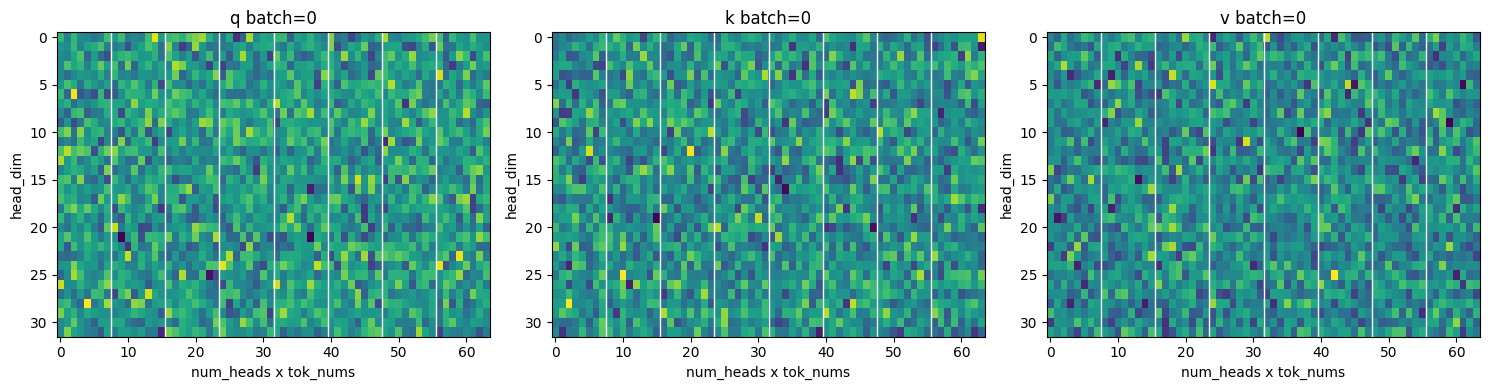

In [ ]:
batch_idx = torch.randint(0, q.shape[0], (1,)).item()

q_img = q[batch_idx].detach().cpu().reshape(num_heads * tok_nums, head_dim).T # [head_dim,num_heads*tok_nums]
k_img = k[batch_idx].detach().cpu().reshape(num_heads * tok_nums, head_dim).T # [head_dim,num_heads*tok_nums]
v_img = v[batch_idx].detach().cpu().reshape(num_heads * tok_nums, head_dim).T # [head_dim,num_heads*tok_nums]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].imshow(q_img, aspect="auto") # [head_dim,num_heads*tok_nums]
ax[0].set_title(f"q batch={batch_idx}")
ax[0].set_xlabel("num_heads x tok_nums")
ax[0].set_ylabel("head_dim")

ax[1].imshow(k_img, aspect="auto") # [head_dim,num_heads*tok_nums]
ax[1].set_title(f"k batch={batch_idx}")
ax[1].set_xlabel("num_heads x tok_nums")
ax[1].set_ylabel("head_dim")

ax[2].imshow(v_img, aspect="auto") # [head_dim,num_heads*tok_nums]
ax[2].set_title(f"v batch={batch_idx}")
ax[2].set_xlabel("num_heads x tok_nums")
ax[2].set_ylabel("head_dim")

for a in ax:
  for h in range(1, num_heads):
    a.axvline(h * tok_nums - 0.5, color="white", linewidth=1)

plt.tight_layout()
plt.show()

So instead 1 huge Attention block we have 8 of them. That means, Attention mechanism does 8 smaller attentions.

In [ ]:
y = F.scaled_dot_product_attention(q, k, v, is_causal=True)  # [batch_size,num_heads,tok_nums,head_dim]
y.shape

torch.Size([10, 8, 8, 32])

Now, lets see how it looks under the hood.

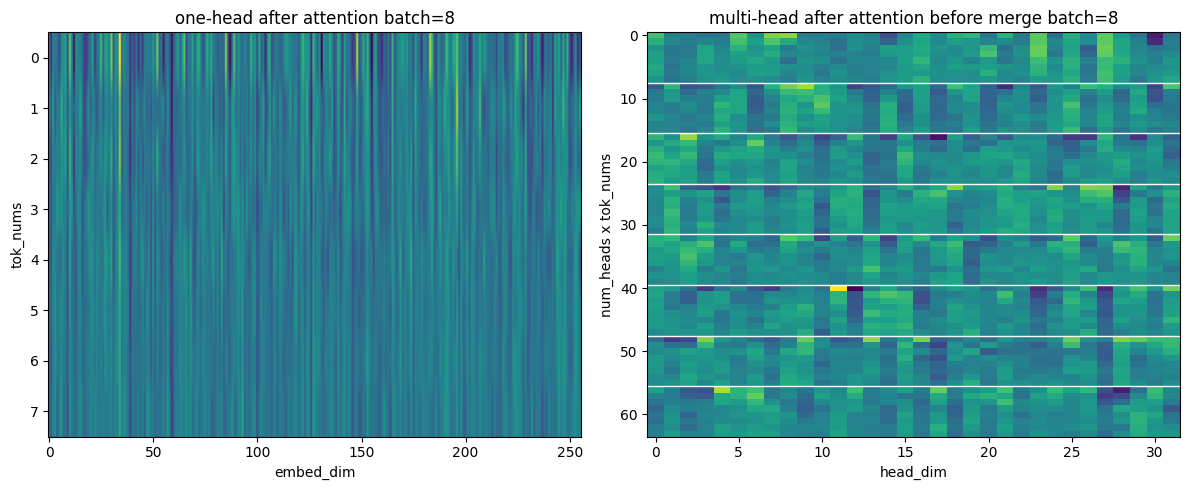

In [ ]:
# x: [batch_size,tok_nums,embed_dim]

batch_size, tok_nums, embed_dim = x.shape
assert embed_dim % num_heads == 0
head_dim = embed_dim // num_heads

# one-head
q_one = nn.Linear(embed_dim, embed_dim, bias=False)(x) # [batch_size,tok_nums,embed_dim]
k_one = nn.Linear(embed_dim, embed_dim, bias=False)(x) # [batch_size,tok_nums,embed_dim]
v_one = nn.Linear(embed_dim, embed_dim, bias=False)(x) # [batch_size,tok_nums,embed_dim]

attn_scores_one = q_one @ k_one.transpose(-2, -1) # [batch_size,tok_nums,tok_nums]
attn_scores_one = attn_scores_one / (embed_dim ** 0.5) # [batch_size,tok_nums,tok_nums]

mask = torch.tril(torch.ones(tok_nums, tok_nums, device=x.device)).bool() # [tok_nums,tok_nums]
attn_scores_one = attn_scores_one.masked_fill(mask == False, float("-inf")) # [batch_size,tok_nums,tok_nums]

attn_weights_one = F.softmax(attn_scores_one, dim=-1) # [batch_size,tok_nums,tok_nums]
y_one = attn_weights_one @ v_one # [batch_size,tok_nums,embed_dim]

# multi-head
q_multi = nn.Linear(embed_dim, embed_dim, bias=False)(x) # [batch_size,tok_nums,embed_dim]
k_multi = nn.Linear(embed_dim, embed_dim, bias=False)(x) # [batch_size,tok_nums,embed_dim]
v_multi = nn.Linear(embed_dim, embed_dim, bias=False)(x) # [batch_size,tok_nums,embed_dim]

q_multi = q_multi.view(batch_size, tok_nums, num_heads, head_dim).transpose(1, 2) # [batch_size,num_heads,tok_nums,head_dim]
k_multi = k_multi.view(batch_size, tok_nums, num_heads, head_dim).transpose(1, 2) # [batch_size,num_heads,tok_nums,head_dim]
v_multi = v_multi.view(batch_size, tok_nums, num_heads, head_dim).transpose(1, 2) # [batch_size,num_heads,tok_nums,head_dim]

attn_scores_multi = q_multi @ k_multi.transpose(-2, -1) # [batch_size,num_heads,tok_nums,tok_nums]
attn_scores_multi = attn_scores_multi / (head_dim ** 0.5) # [batch_size,num_heads,tok_nums,tok_nums]

attn_scores_multi = attn_scores_multi.masked_fill(mask == False, float("-inf")) # [batch_size,num_heads,tok_nums,tok_nums]

attn_weights_multi = F.softmax(attn_scores_multi, dim=-1) # [batch_size,num_heads,tok_nums,tok_nums]
y_multi = attn_weights_multi @ v_multi # [batch_size,num_heads,tok_nums,head_dim]

# plot: one-head after attention vs multi-head after attention before merge
batch_idx = torch.randint(0, batch_size, (1,)).item()

one_img = y_one[batch_idx].detach().cpu() # [tok_nums,embed_dim]
multi_img = y_multi[batch_idx].detach().cpu().reshape(num_heads * tok_nums, head_dim) # [num_heads*tok_nums,head_dim]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(one_img, aspect="auto") # [tok_nums,embed_dim]
ax[0].set_title(f"one-head after attention batch={batch_idx}")
ax[0].set_xlabel("embed_dim")
ax[0].set_ylabel("tok_nums")

ax[1].imshow(multi_img, aspect="auto") # [num_heads*tok_nums,head_dim]
ax[1].set_title(f"multi-head after attention before merge batch={batch_idx}")
ax[1].set_xlabel("head_dim")
ax[1].set_ylabel("num_heads x tok_nums")

for h in range(1, num_heads):
  ax[1].axhline(h * tok_nums - 0.5, color="white", linewidth=1)

plt.tight_layout()
plt.show()

As we can see, instead of keeping the last dimension as `embed_dim = 256`, we split it into two dimensions: `num_heads = 8` and `head_dim = 32`.

This means we now have 8 separate attention heads. Previously, each token was represented by a single 256-dimensional vector for attention. Now, each token is represented as 8 smaller 32-dimensional vectors, one for each attention head.

In [ ]:
# [batch_size,num_heads,tok_nums,head_dim] -> [batch_size,tok_nums,num_heads,head_dim] -> [batch_size,tok_nums,embed_dim]
y = y.transpose(1, 2).contiguous().view(batch_size, tok_nums, embed_dim)

y = W0(y)  # [batch_size,tok_nums,embed_dim]

Eventually, we merge [`num_heads`, `head_dim`] back into `embed_dim`.

The transpositions are mostly there because PyTorch's built-in `F.scaled_dot_product_attention` expects tensors in the shape:

`[batch_size, num_heads, tok_nums, head_dim]`

So they are not a deep mathematical operation, just a tensor-layout requirement for the function.

The simple conclusion, without romanticizing it, is this:

Instead of computing one attention mechanism over a 256-dimensional token representation, we split it into 8 separate attention heads, each working on 32 dimensions.

So conceptually:

`1 × 256 -> 8 × 32`

The total dimension stays the same, but attention is computed in 8 separate subspaces.

**OK, BUT WHY WE'RE DOING THIS?**

There is no simple mathematical theorem saying that multi-head attention must always be better.

It is mostly an architectural intuition confirmed empirically: by splitting one large attention mechanism into several smaller heads, the model can learn different attention patterns in parallel. **For example, one head may focus on local context, another on syntax, another on long-range dependencies, etc.**. Of course this is intuition, no one will tell us which attention learned exactly what.

# Model 4 - Full GPT on GPU

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

from transformers import GPT2Tokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu' # NEW
device

'cpu'

## Hyperparameters

In [2]:
batch_size = 8
embed_dim  = 768   # embedding dimension
seq_len    = 1024  # max sequence length

tokenizer  = GPT2Tokenizer.from_pretrained('GPT2')
n_vocab    = 50257 # GPT2 vocab size

n_transformer_blocks = 12 # transformer blocks
num_heads  = 12    # attention heads

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Multi Head Attention

In [3]:
class MultiHeadAttention(nn.Module):
  def __init__(self):
    super().__init__()

    assert embed_dim % num_heads == 0

    self.head_dim = embed_dim // num_heads

    self.q = nn.Linear(embed_dim, embed_dim, bias = False)
    self.k = nn.Linear(embed_dim, embed_dim, bias = False)
    self.v = nn.Linear(embed_dim, embed_dim, bias = False)

    self.W0 = nn.Linear(embed_dim, embed_dim)

  def forward(self, x):

    batch_size, tok_num = x.shape[0], x.shape[1]

    q = self.q(x) # [batch_size, tok_num, embed_dim]
    k = self.k(x) # [batch_size, tok_num, embed_dim]
    v = self.v(x) # [batch_size, tok_num, embed_dim]

    q = q.view(batch_size, tok_num, num_heads, self.head_dim).transpose(1,2) # [batch_size, num_heads, tok_num, head_dim]
    k = k.view(batch_size, tok_num, num_heads, self.head_dim).transpose(1,2) # [batch_size, num_heads, tok_num, head_dim]
    v = v.view(batch_size, tok_num, num_heads, self.head_dim).transpose(1,2) # [batch_size, num_heads, tok_num, head_dim]

    y = F.scaled_dot_product_attention(q, k, v, is_causal = True)

    y = y.transpose(1,2).contiguous().view(batch_size, tok_num, embed_dim) # [batch_size, tok_num, embed_dim]

    y = self.W0(y)

    return y

In [4]:
x = torch.randn(batch_size, seq_len, embed_dim)

mha = MultiHeadAttention()
y = mha(x)
y.shape

torch.Size([8, 1024, 768])

## Transformer Block

In [5]:
class TransformerBlock(nn.Module):
  def __init__(self):
    super().__init__()

    # attn
    self.layer_norm_attn = nn.LayerNorm(embed_dim)
    self.attn            = MultiHeadAttention()

    # mlp
    self.layer_norm_mlp = nn.LayerNorm(embed_dim)
    self.W1             = nn.Linear(embed_dim, 4*embed_dim)
    self.gelu           = nn.GELU()
    self.W2             = nn.Linear(4*embed_dim, embed_dim)

  def forward(self, x):

    # attn
    x = x + self.attn(self.layer_norm_attn(x))

    # mlp
    x = x + self.W2(self.gelu(self.W1(self.layer_norm_mlp(x))))

    return x

In [6]:
tb = TransformerBlock()
y = tb(x)
y.shape

torch.Size([8, 1024, 768])

## Model

In [7]:
class Model(nn.Module):
  def __init__(self, gpu):
    super().__init__()

    self.gpu = gpu

    self.token_embeddings = nn.Embedding(n_vocab, embed_dim)
    self.posit_embeddings = nn.Embedding(seq_len, embed_dim)

    self.n_transformer_blocks = nn.Sequential(*[TransformerBlock() for _ in range(n_transformer_blocks)])

    self.final_layer_norm   = nn.LayerNorm(embed_dim)
    self.final_layer        = nn.Linear(embed_dim, n_vocab)
    self.final_layer.weight = nn.Parameter(self.token_embeddings.weight)

  def forward(self, tok_x):

    token_embeddings = self.token_embeddings(tok_x)
    if self.gpu:
      posit_embeddings = self.posit_embeddings(torch.arange(tok_x.shape[-1], device = device)) # NEW
    else:
      posit_embeddings = self.posit_embeddings(torch.arange(tok_x.shape[-1]))

    x = token_embeddings + posit_embeddings

    x = self.n_transformer_blocks(x)

    x = self.final_layer_norm(x)
    x = self.final_layer(x)

    return x

  def generate(self, tok_x, temperature, n_tok_gen):

    for _ in range(n_tok_gen):
      x        = self(tok_x[:,-seq_len:]) # [batch_size, seq_len, n_vocab]
      logs     = x[:,-1,:] # [batch_size, n_vocab]
      probs    = F.softmax(logs/temperature, dim = -1) # [batch_size, n_vocab]
      tok_next = torch.multinomial(probs, num_samples = 1) # [batch_size, 1]
      tok_x    = torch.cat((tok_x, tok_next), dim = 1) # [batch_size, seq_len+1]

    return tok_x

## Generate Text

### GPU

In [8]:
import time

tok_x = torch.randint(0, n_vocab, (batch_size, seq_len))
tok_x = tok_x.to(device)

model = Model(gpu=True).to(device)

start_time = time.time()

y_gen = model.generate(tok_x, temperature=2, n_tok_gen=20)

end_time = time.time()

print("Generated shape:", y_gen.shape)
print("Generation time:", end_time - start_time, "seconds")

Generated shape: torch.Size([8, 1044])
Generation time: 189.17024636268616 seconds


### CPU

In [9]:
import time

tok_x = torch.randint(0, n_vocab, (batch_size, seq_len))

model = Model(gpu=False)

start_time = time.time()

y_gen = model.generate(tok_x, temperature=2, n_tok_gen=20)

end_time = time.time()

print("Generated shape:", y_gen.shape)
print("Generation time:", end_time - start_time, "seconds")

Generated shape: torch.Size([8, 1044])
Generation time: 184.24253106117249 seconds


We can see that GPU is multiple times faster and this is only for generating 20 `n_tok_gen`, the more we generate the higher difference will be.

## Deconstruction

### Move to GPU

Only 3 places:

```python
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Model().to(device)
tok_x = tok_x.to(device)
```

And in `forward`:

```python
torch.arange(tok_x.shape[-1], device=tok_x.device)
```

Done.

`Model().to(device)` moves everything to GPU created in `Model.__init__()`. It doesn't move to device tensors newly created in `forward()`. The only tensor which is newly created is `torch.arange()` that's why we need to move it manually to device.

### Parameters count

In [12]:
model

Model(
  (token_embeddings): Embedding(50257, 768)
  (posit_embeddings): Embedding(1024, 768)
  (n_transformer_blocks): Sequential(
    (0): TransformerBlock(
      (layer_norm_attn): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (W0): Linear(in_features=768, out_features=768, bias=True)
      )
      (layer_norm_mlp): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (W1): Linear(in_features=768, out_features=3072, bias=True)
      (gelu): GELU(approximate='none')
      (W2): Linear(in_features=3072, out_features=768, bias=True)
    )
    (1): TransformerBlock(
      (layer_norm_attn): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (q): Linear(in_features=768, out_features=768, bi

In [10]:
!pip install torchinfo
from torchinfo import summary

summary(model, input_data = tok_x, col_names = ['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Model                                    [8, 1024]                 [8, 1024, 50257]          --
├─Embedding: 1-1                         [8, 1024]                 [8, 1024, 768]            38,597,376
├─Embedding: 1-2                         [1024]                    [1024, 768]               786,432
├─Sequential: 1-3                        [8, 1024, 768]            [8, 1024, 768]            --
│    └─TransformerBlock: 2-1             [8, 1024, 768]            [8, 1024, 768]            --
│    │    └─LayerNorm: 3-1               [8, 1024, 768]            [8, 1024, 768]            1,536
│    │    └─MultiHeadAttention: 3-2      [8, 1024, 768]            [8, 1024, 768]            2,360,064
│    │    └─LayerNorm: 3-3               [8, 1024, 768]            [8, 1024, 768]            1,536
│    │    └─Linear: 3-4                  [8, 1024, 768]            [8, 1024, 3072]           2,362,368
│ 

# Model 5 - Inspecting Original GPT

In [2]:
import torch
from transformers import AutoModelForCausalLM, GPT2Tokenizer

!pip install torchinfo
from torchinfo import summary

## Load

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2      = AutoModelForCausalLM.from_pretrained('gpt2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [4]:
x = torch.tensor(tokenizer.encode('Hello, how are you today')).unsqueeze(0)

summary(gpt2, input_data = x)

Layer (type:depth-idx)                             Output Shape              Param #
GPT2LMHeadModel                                    --                        --
├─GPT2Model: 1-1                                   --                        --
│    └─Embedding: 2-1                              [1, 6, 768]               38,597,376
│    └─Embedding: 2-2                              [1, 6, 768]               786,432
│    └─Dropout: 2-3                                [1, 6, 768]               --
│    └─ModuleList: 2-4                             --                        --
│    │    └─GPT2Block: 3-1                         [1, 6, 768]               7,087,872
│    │    └─GPT2Block: 3-2                         [1, 6, 768]               7,087,872
│    │    └─GPT2Block: 3-3                         [1, 6, 768]               7,087,872
│    │    └─GPT2Block: 3-4                         [1, 6, 768]               7,087,872
│    │    └─GPT2Block: 3-5                         [1, 6, 768]            

In [5]:
gpt2

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [6]:
gpt2.transformer.h[11]

GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

In [7]:
for name, mat in gpt2.named_parameters():
  print(f'{name:>40} is of size: {mat.shape}')

                  transformer.wte.weight is of size: torch.Size([50257, 768])
                  transformer.wpe.weight is of size: torch.Size([1024, 768])
             transformer.h.0.ln_1.weight is of size: torch.Size([768])
               transformer.h.0.ln_1.bias is of size: torch.Size([768])
      transformer.h.0.attn.c_attn.weight is of size: torch.Size([768, 2304])
        transformer.h.0.attn.c_attn.bias is of size: torch.Size([2304])
      transformer.h.0.attn.c_proj.weight is of size: torch.Size([768, 768])
        transformer.h.0.attn.c_proj.bias is of size: torch.Size([768])
             transformer.h.0.ln_2.weight is of size: torch.Size([768])
               transformer.h.0.ln_2.bias is of size: torch.Size([768])
         transformer.h.0.mlp.c_fc.weight is of size: torch.Size([768, 3072])
           transformer.h.0.mlp.c_fc.bias is of size: torch.Size([3072])
       transformer.h.0.mlp.c_proj.weight is of size: torch.Size([3072, 768])
         transformer.h.0.mlp.c_proj.bia

Generate some text

In [10]:
out = gpt2.generate(x, temperature = 1, do_sample = True, max_length = 100, pad_token_id = tokenizer.eos_token_id)
print(tokenizer.decode(out[0].tolist()))

Hello, how are you today?

"The first day of school is like learning to read for the first time," he said. "Your first class in my house is called 'A Roomful of Dressed People,' which I remember as 'Gore in Your Shoes.' " I wanted to write about them on my blog, because I remember thinking, Oh! This is such a small world. What a big world! We can go to every school and you're in a world called
